# 1. master data aggregator
Ephys CSV: Reads only the single most recent CSV file from Aipfx_extfeatures_SSL.

Mapping CSVs: Reads and concatenates all (1+) CSV files in Aipfx_mapping_SSL.

Reclassification Tracking: Identifies cells with a reclassified_cell_type. It creates explicit tracking columns (cell_type_final, is_reclassified, and reclassification_status) so you can easily filter them out or plot using their updated classification.

In [2]:
import os
import re
import glob
import pandas as pd
import numpy as np

# =============================================================================
# 1. PATH CONFIGURATION
# =============================================================================
ephys_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_extfeatures_SSL"
mapping_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_mapping_SSL"

def clean_key(val):
    """Standardizes cell identifier string across all files."""
    s = str(val).lower().strip()
    s = re.sub(r'[^\x00-\x7F]+', '', s)  # Remove non-ASCII/zero-width spaces
    s = os.path.basename(s).replace('.nwb', '').replace('_compressed', '').replace('-compressed', '')
    return re.sub(r'_itc18usb_dev_\d+', '', s).strip()

print("=" * 100)
print("🚀 LEFT MERGE: KEEP ALL EPHYS DATA + ATTACH REQUESTED MAPPING COLUMNS")
print("=" * 100)

# =============================================================================
# 2. LOAD LATEST EPHYS CSV (PRIMARY BASE DATASET)
# =============================================================================
ephys_files = glob.glob(os.path.join(ephys_folder, "*.csv"))
if not ephys_files:
    raise FileNotFoundError(f"No ephys CSV files found in {ephys_folder}")

latest_ephys_file = max(ephys_files, key=os.path.getmtime)
print(f"📁 Selected LATEST Ephys File:\n   • {os.path.basename(latest_ephys_file)}")

df_ephys = pd.read_csv(latest_ephys_file)

ephys_id_col = [c for c in df_ephys.columns if c.lower() in ['cell_name', 'target_cell', 'cell', 'file_path']][0]
df_ephys['cell_key'] = df_ephys[ephys_id_col].apply(clean_key)
df_ephys = df_ephys.drop_duplicates(subset=['cell_key'], keep='last')

ephys_target_keys = set(df_ephys['cell_key'].unique())
print(f"   • Primary Ephys dataset: {len(df_ephys)} cells loaded.")

# =============================================================================
# 3. LOAD ALL MAPPING CSVs & FILTER FOR REQUESTED COLUMNS
# =============================================================================
mapping_files = glob.glob(os.path.join(mapping_folder, "*.csv"))
mapping_files.sort(key=os.path.getmtime)

if not mapping_files:
    raise FileNotFoundError(f"No mapping CSV files found in {mapping_folder}")

print(f"\n📁 Scanning {len(mapping_files)} Mapping CSVs...")
map_dfs = [pd.read_csv(mf) for mf in mapping_files]
df_all_map = pd.concat(map_dfs, ignore_index=True)

# Detect cell identifier in mapping
map_id_col = [c for c in df_all_map.columns if c.lower() in ['cell', 'cell_name', 'sample_id', 'target_cell', 'specimen_name']][0]
df_all_map['cell_key'] = df_all_map[map_id_col].apply(clean_key)

# Filter mapping source: PLS4_ container OR key match to Ephys dataset
container_col = 'patched_cell_container' if 'patched_cell_container' in df_all_map.columns else None
is_ephys_match = df_all_map['cell_key'].isin(ephys_target_keys)

if container_col:
    is_pls4_container = df_all_map[container_col].astype(str).str.upper().str.contains('PLS4_', na=False)
    filter_mask = is_pls4_container | is_ephys_match
else:
    filter_mask = is_ephys_match

df_filtered_map = df_all_map[filter_mask].copy()

# Deduplicate mapping rows (keep latest RSC batch metadata per cell_key)
df_master_map = df_filtered_map.drop_duplicates(subset=['cell_key'], keep='last').copy()

# Exact list of requested mapping columns
REQUESTED_MAPPING_COLS = [
    'tubeID', 'patched_cell_container', 'cell_name', 'cell_id',
    'percent_cdna_longer_than_400bp', 'rna_amplification_pass_fail',
    'amplified_quantity_ng', 'total_reads', 'percent_reads_aligned_total',
    'Genes.Detected.CPM', 'prob', 'avg.dist', 'avg.path.cor',
    'avg.cor', 'cor.zscore', 'best.subclass_label', 'best.class_label',
    'best.supertype_label'
]

# Extract available requested columns (+ cell_key for joining)
available_map_cols = [c for c in REQUESTED_MAPPING_COLS if c in df_master_map.columns]
df_map_subset = df_master_map[['cell_key'] + available_map_cols].copy()

print(f"   • Extracted {len(available_map_cols)} / {len(REQUESTED_MAPPING_COLS)} requested mapping columns.")

# =============================================================================
# 4. LEFT MERGE (PRESERVE ALL EPHYS DATA)
# =============================================================================
# how='left' ensures 100% of Ephys rows are preserved
df_merged = pd.merge(
    df_ephys, 
    df_map_subset, 
    on='cell_key', 
    how='left', 
    suffixes=('', '_map')
)

# Benchmark mapping metadata attachment
primary_subclass_col = 'best.subclass_label' if 'best.subclass_label' in df_merged.columns else available_map_cols[0]
mapped_count = df_merged[primary_subclass_col].notna().sum()
unmapped_count = df_merged[primary_subclass_col].isna().sum()

print("\n" + "=" * 100)
print("🎉 LEFT MERGE COMPLETE!")
print("=" * 100)
print(f"• Total Ephys Rows Preserved : {len(df_merged)} / {len(df_ephys)}")
print(f"• Cells WITH Mapping Data   : {mapped_count}")
print(f"• Cells WITHOUT Mapping Data: {unmapped_count} (Retained as NaN for sequencing columns)")

🚀 LEFT MERGE: KEEP ALL EPHYS DATA + ATTACH REQUESTED MAPPING COLUMNS
📁 Selected LATEST Ephys File:
   • SSL_M_ephys_features_20261001_133255.csv
   • Primary Ephys dataset: 229 cells loaded.

📁 Scanning 2 Mapping CSVs...


C:\Users\samantha.lee\AppData\Local\Temp\ipykernel_26764\1121462184.py:53: DtypeWarning: Columns (28,33,34,35,36,39,94,112,122,124,134) have mixed types. Specify dtype option on import or set low_memory=False.
  map_dfs = [pd.read_csv(mf) for mf in mapping_files]


   • Extracted 18 / 18 requested mapping columns.

🎉 LEFT MERGE COMPLETE!
• Total Ephys Rows Preserved : 229 / 229
• Cells WITH Mapping Data   : 28
• Cells WITHOUT Mapping Data: 201 (Retained as NaN for sequencing columns)


## save as CSV in mapping server folder

In [ ]:
import os
from datetime import datetime

# Network destination
output_dir = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_mapping_SSL"
os.makedirs(output_dir, exist_ok=True)

# Timestamped filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"SSL_M_ephys_mapping_{timestamp}.csv"
full_save_path = os.path.join(output_dir, filename)

# Save merged dataset
df_merged.to_csv(full_save_path, index=False)

print("=" * 90)
print("💾 MASTER ELECT PHYSIOLOGY & TRANSCRIPTOMICS (ET) DATASET SAVED")
print("=" * 90)
print(f"• Saved Path   : {full_save_path}")
print(f"• Total Rows   : {len(df_merged)}")
print(f"• Total Columns: {len(df_merged.columns)}")

# 2. plotting all cells

## 2a. Defined ABC Atlas Palette, Cell Counts Bar Chart, & 6-Panel Ephys Summary Grid (Matching Reference Figure)

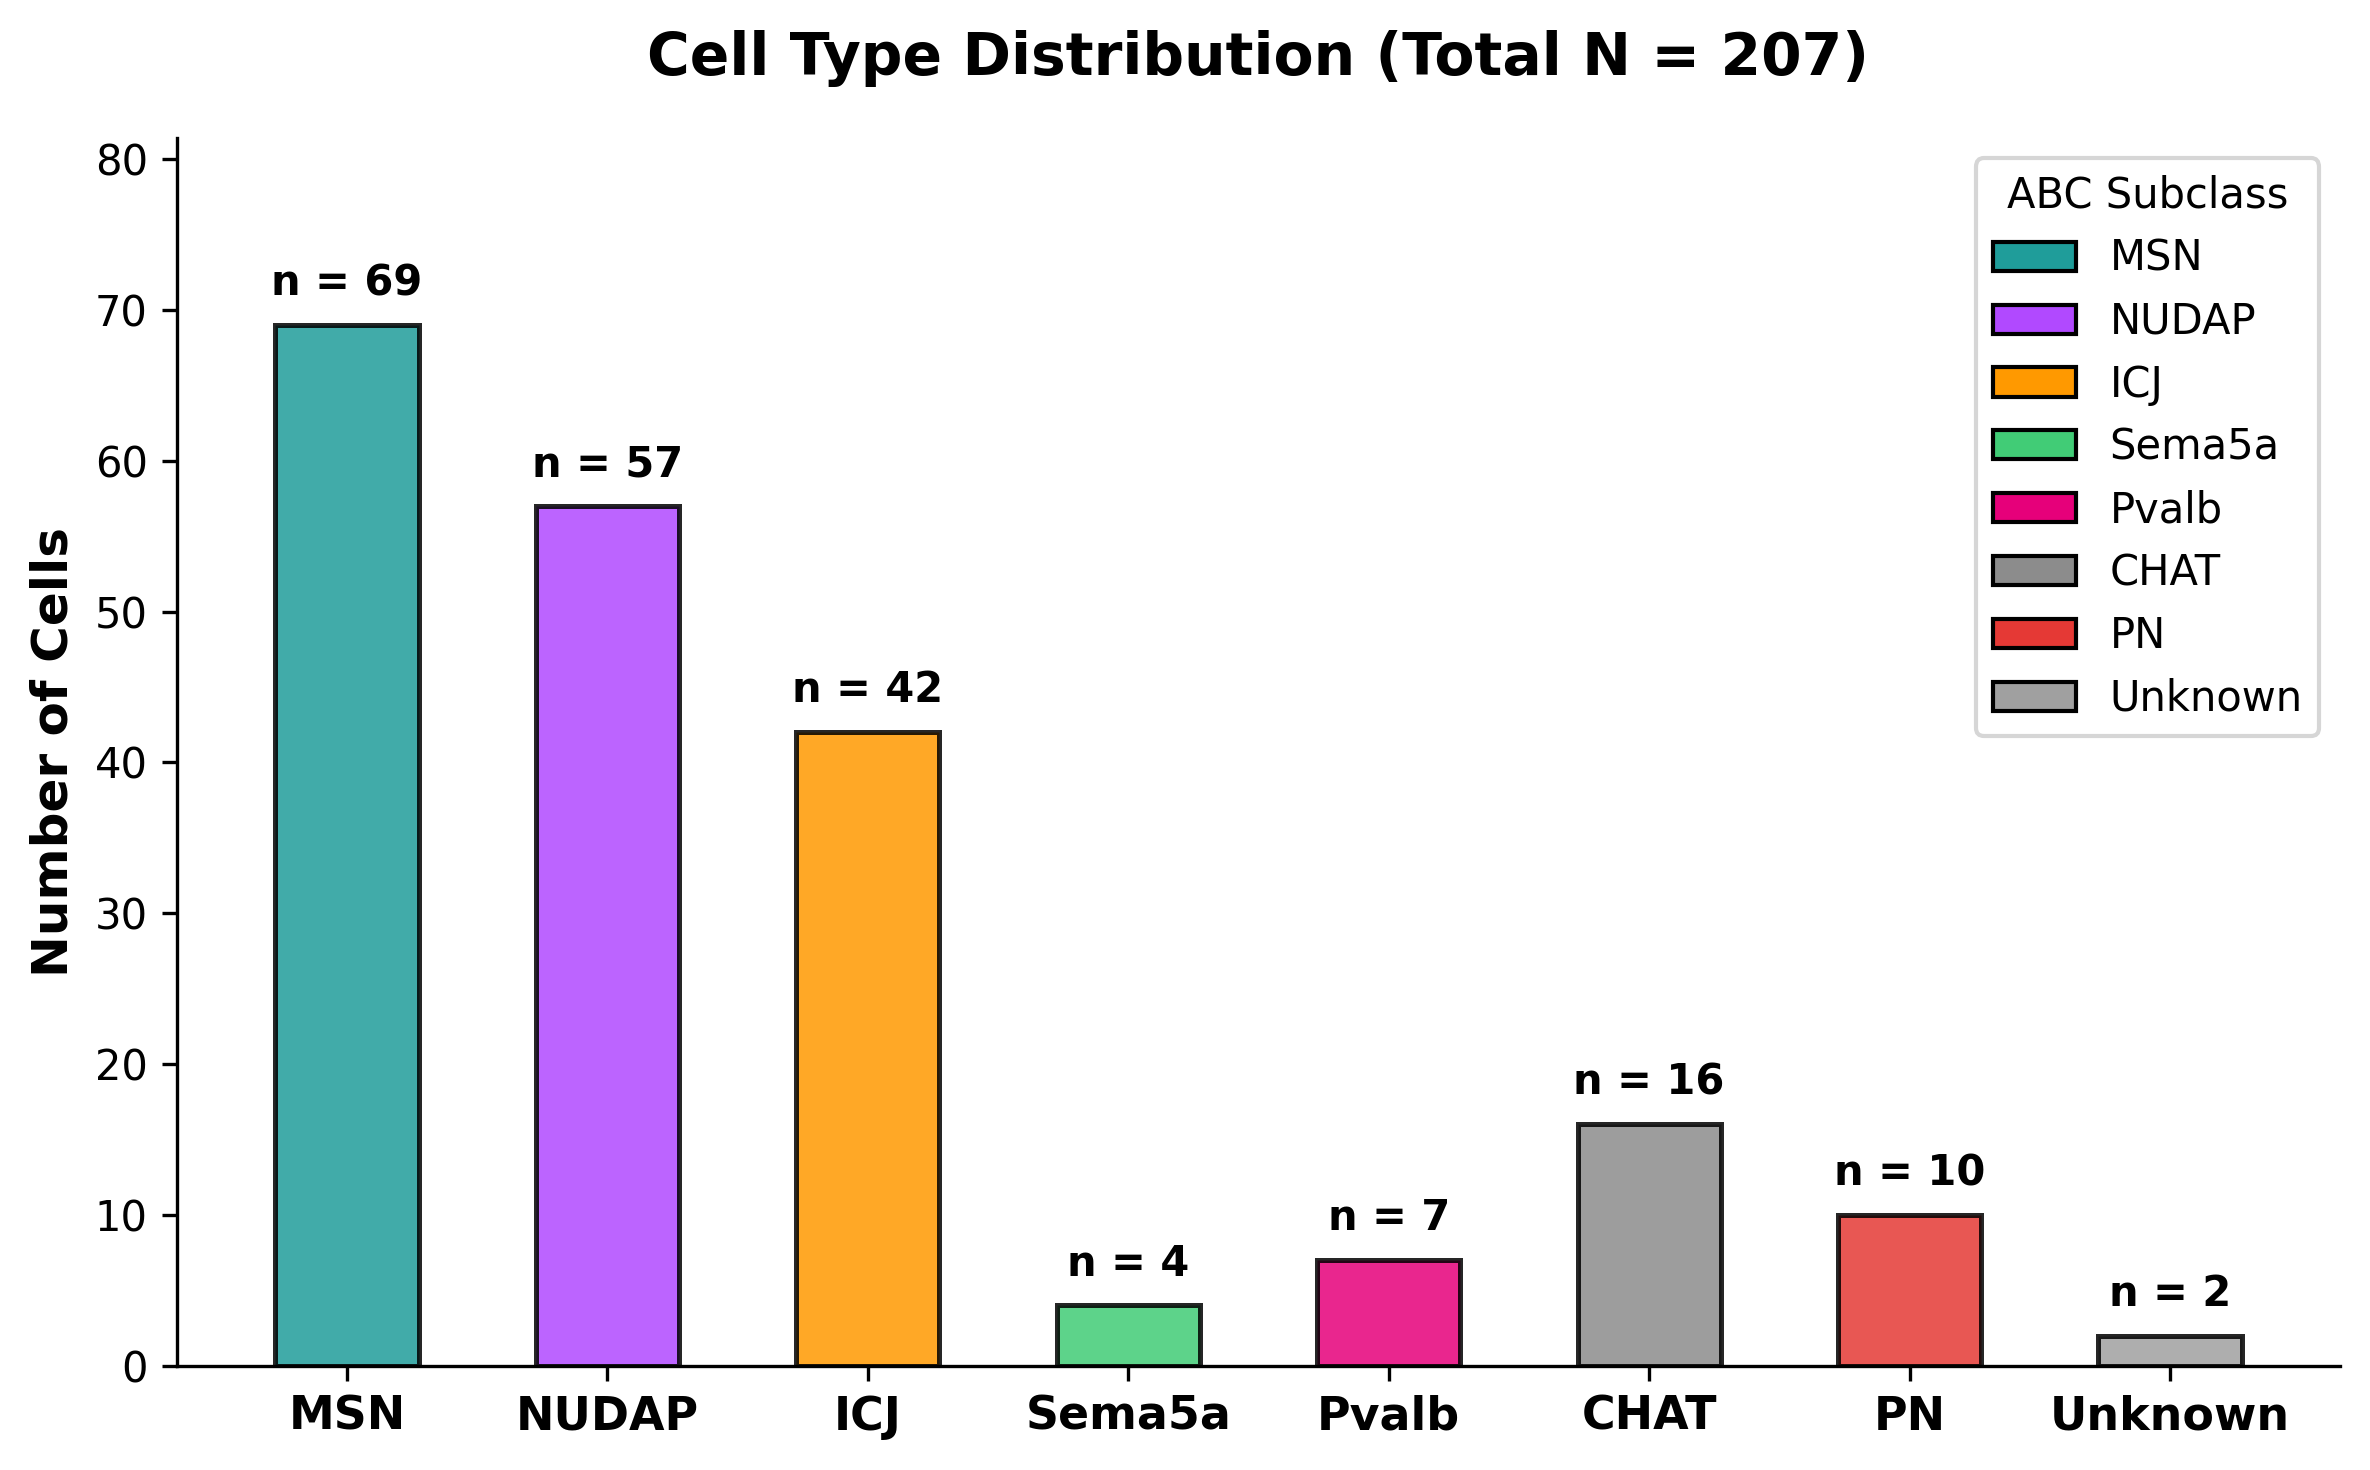

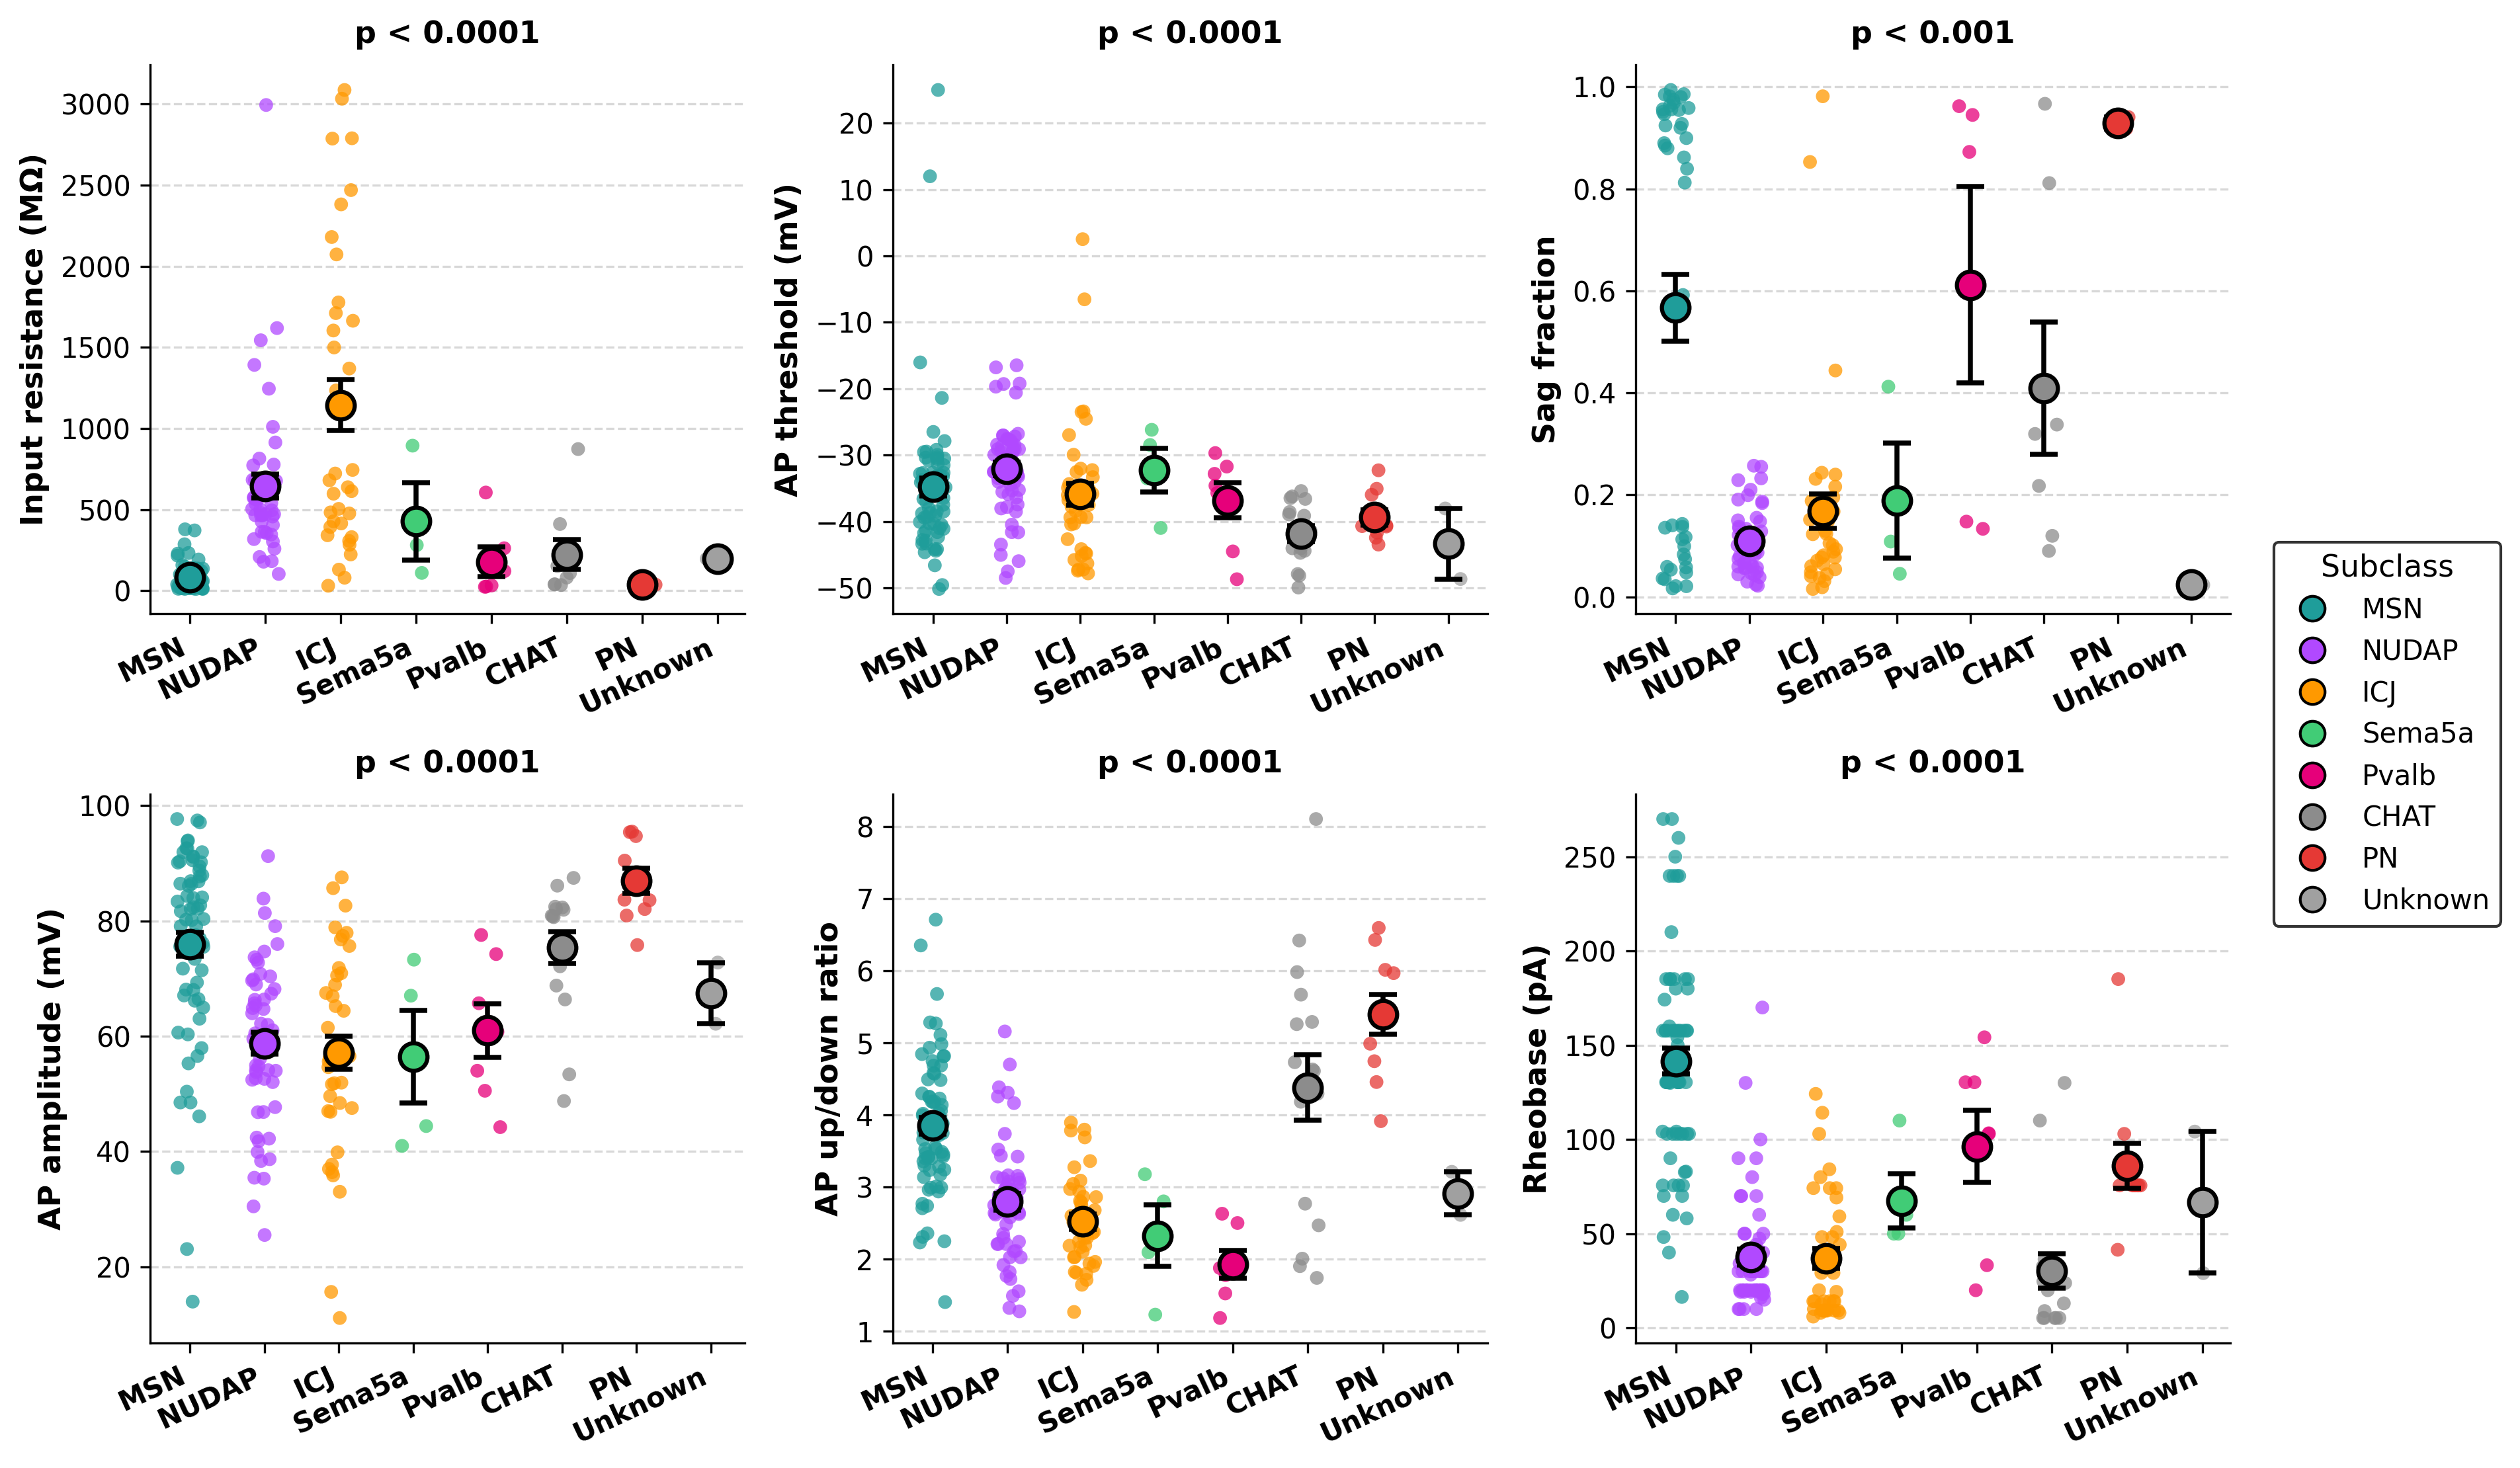

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

np.random.seed(42)

# =============================================================================
# 1. DEFINE EXACT CATEGORY ORDER & ABC ATLAS PALETTE
# =============================================================================
EXACT_CELL_ORDER = [
    "MSN",
    "NUDAP",
    "ICJ",
    "Sema5a",
    "Pvalb",
    "CHAT",
    "PN",
    "Unknown",
]

ABC_WMB_PALETTE = {
    "MSN": "#1F9D9A",      # Teal
    "NUDAP": "#B149FF",    # Purple / Magenta
    "ICJ": "#FF9900",      # Orange / Gold
    "Sema5a": "#41CC76",   # Mint Green
    "Pvalb": "#E6007A",    # Fast-Spiking Parvalbumin (Vibrant Magenta-Red)
    "CHAT": "#8C8C8C",     # Slate Grey (Cholinergic)
    "PN": "#E53935",       # Red (Pyramidal / Projection Neurons)
    "Unknown": "#A0A0A0"   # Light Grey
}

# =============================================================================
# 2. CONSOLIDATE CELL TYPES TO MATCH YOUR EXACT NAMES
# =============================================================================
def consolidate_cell_type(val):
    if pd.isna(val) or str(val).strip().lower() in ['nan', 'none', '', 'null']:
        return np.nan
        
    s = str(val).strip().upper()
    
    if 'MSN' in s:
        return 'MSN'
    elif 'NUDAP' in s:
        return 'NUDAP'
    elif 'ICJ' in s:
        return 'ICJ'
    elif 'SEMA5A' in s:
        return 'Sema5a'
    elif 'PVALB' in s:
        return 'Pvalb'
    elif 'CHAT' in s or 'CHOLINERGIC' in s:
        return 'CHAT'
    elif any(k in s for k in ['PN', 'CTX', 'L5ET', 'PYRAMIDAL']):
        return 'PN'
    elif 'UNKNOWN' in s:
        return 'Unknown'
    return str(val).strip()

# Target column selection
raw_type_col = 'cell_type_targeted' if 'cell_type_targeted' in df_merged.columns else 'cell_type_final'
df_merged['cell_type_consolidated'] = df_merged[raw_type_col].apply(consolidate_cell_type)

# Drop NaN entries
df_clean = df_merged.dropna(subset=['cell_type_consolidated']).copy()
TOTAL_N = len(df_clean)

# Filter predefined order to include only cell types present in dataset
present_types = set(df_clean['cell_type_consolidated'].unique())
cell_order = [c for c in EXACT_CELL_ORDER if c in present_types]

# Append any unlisted categories to the end
extra_types = [c for c in present_types if c not in EXACT_CELL_ORDER]
cell_order.extend(extra_types)

# Get cell counts in custom order
counts = df_clean['cell_type_consolidated'].value_counts()
color_map = {c: ABC_WMB_PALETTE.get(c, "#7F7F7F") for c in cell_order}

# =============================================================================
# 3. DISTRIBUTION BAR CHART IN CUSTOM ORDER
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

x_pos = np.arange(len(cell_order))
bar_heights = [counts.get(c, 0) for c in cell_order]
bar_colors = [color_map[c] for c in cell_order]

bars = ax.bar(
    x_pos, 
    bar_heights, 
    color=bar_colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85,
    width=0.55
)

# Label counts
for bar, count in zip(bars, bar_heights):
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + (max(bar_heights) * 0.02), 
        f"n = {count}", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(cell_order, rotation=0, fontweight='bold', fontsize=11)
ax.set_ylabel("Number of Cells", fontsize=12, fontweight='bold')
ax.set_title(f"Cell Type Distribution (Total N = {TOTAL_N})", fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(bar_heights) * 1.18)

# Legend
legend_handles = [plt.Rectangle((0,0),1,1, color=color_map[c], ec='black') for c in cell_order]
ax.legend(legend_handles, cell_order, title="ABC Subclass", frameon=True, facecolor='white', loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. 6-PANEL EPHYS GRID IN CUSTOM ORDER
# =============================================================================

EPHYS_PANELS = [
    ("input_resistance(mOhms)", "Input resistance (MΩ)"),
    ("rheobase_sweep_threshold_v(mV)", "AP threshold (mV)"),
    ("sag_fraction", "Sag fraction"),
    ("rheobase_sweep_ap_amplitude(mV)", "AP amplitude (mV)"),
    ("rheobase_sweep_upstroke_downstroke_ratio", "AP up/down ratio"),
    ("rheobase_sweep_stim_amp(pA)", "Rheobase (pA)")
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), dpi=300)
axes = axes.flatten()

for idx, (feat_col, label) in enumerate(EPHYS_PANELS):
    ax = axes[idx]
    sub_df = df_clean.dropna(subset=[feat_col, 'cell_type_consolidated']).copy()
    present_order = [c for c in cell_order if c in sub_df['cell_type_consolidated'].unique()]
    
    if len(present_order) == 0:
        ax.set_visible(False)
        continue

    for g_idx, grp in enumerate(present_order):
        grp_vals = sub_df[sub_df['cell_type_consolidated'] == grp][feat_col].dropna().values
        if len(grp_vals) > 0:
            grp_color = color_map[grp]
            
            # Jittered scatter points
            jitter = np.random.uniform(-0.18, 0.18, size=len(grp_vals))
            ax.scatter(g_idx + jitter, grp_vals, color=grp_color, s=25, alpha=0.75, edgecolors='none', zorder=3)
            
            # Mean dot + SEM error bar
            mean_val = np.mean(grp_vals)
            sem_val = (np.std(grp_vals, ddof=1) / np.sqrt(len(grp_vals))) if len(grp_vals) > 1 else 0.0
            
            ax.scatter(g_idx, mean_val, color=grp_color, s=100, edgecolors='black', linewidths=1.5, zorder=5)
            ax.errorbar(g_idx, mean_val, yerr=sem_val, fmt='none', ecolor='black', elinewidth=1.8, capsize=5, capthick=1.8, zorder=4)

    # Statistical Test Annotations
    if len(present_order) > 2:
        group_arrays = [sub_df[sub_df['cell_type_consolidated'] == g][feat_col].dropna().values for g in present_order]
        valid_arrays = [a for a in group_arrays if len(a) >= 2]
        if len(valid_arrays) > 1:
            _, p_val = kruskal(*valid_arrays)
            p_str = "p < 0.0001" if p_val < 0.0001 else f"p = {p_val:.3f}" if p_val >= 0.001 else f"p < 0.001"
            ax.set_title(p_str, fontsize=11, fontweight='bold', pad=8)

    ax.set_xticks(np.arange(len(present_order)))
    ax.set_xticklabels(present_order, rotation=25, ha='right', fontweight='bold', fontsize=10)
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='grey')
    ax.set_axisbelow(True)

# Create single legend placed outside the figure on the right
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[c], markeredgecolor='black', markersize=9) 
    for c in cell_order
]

fig.legend(
    handles=legend_handles, 
    labels=cell_order, 
    title="Subclass", 
    title_fontsize='11',
    fontsize='10',
    frameon=True, 
    facecolor='white', 
    edgecolor='black',
    loc='center left', 
    bbox_to_anchor=(0.88, 0.5)  # Positions legend outside on far right
)

# Leave space on right for legend
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## 2b. cell mapping results

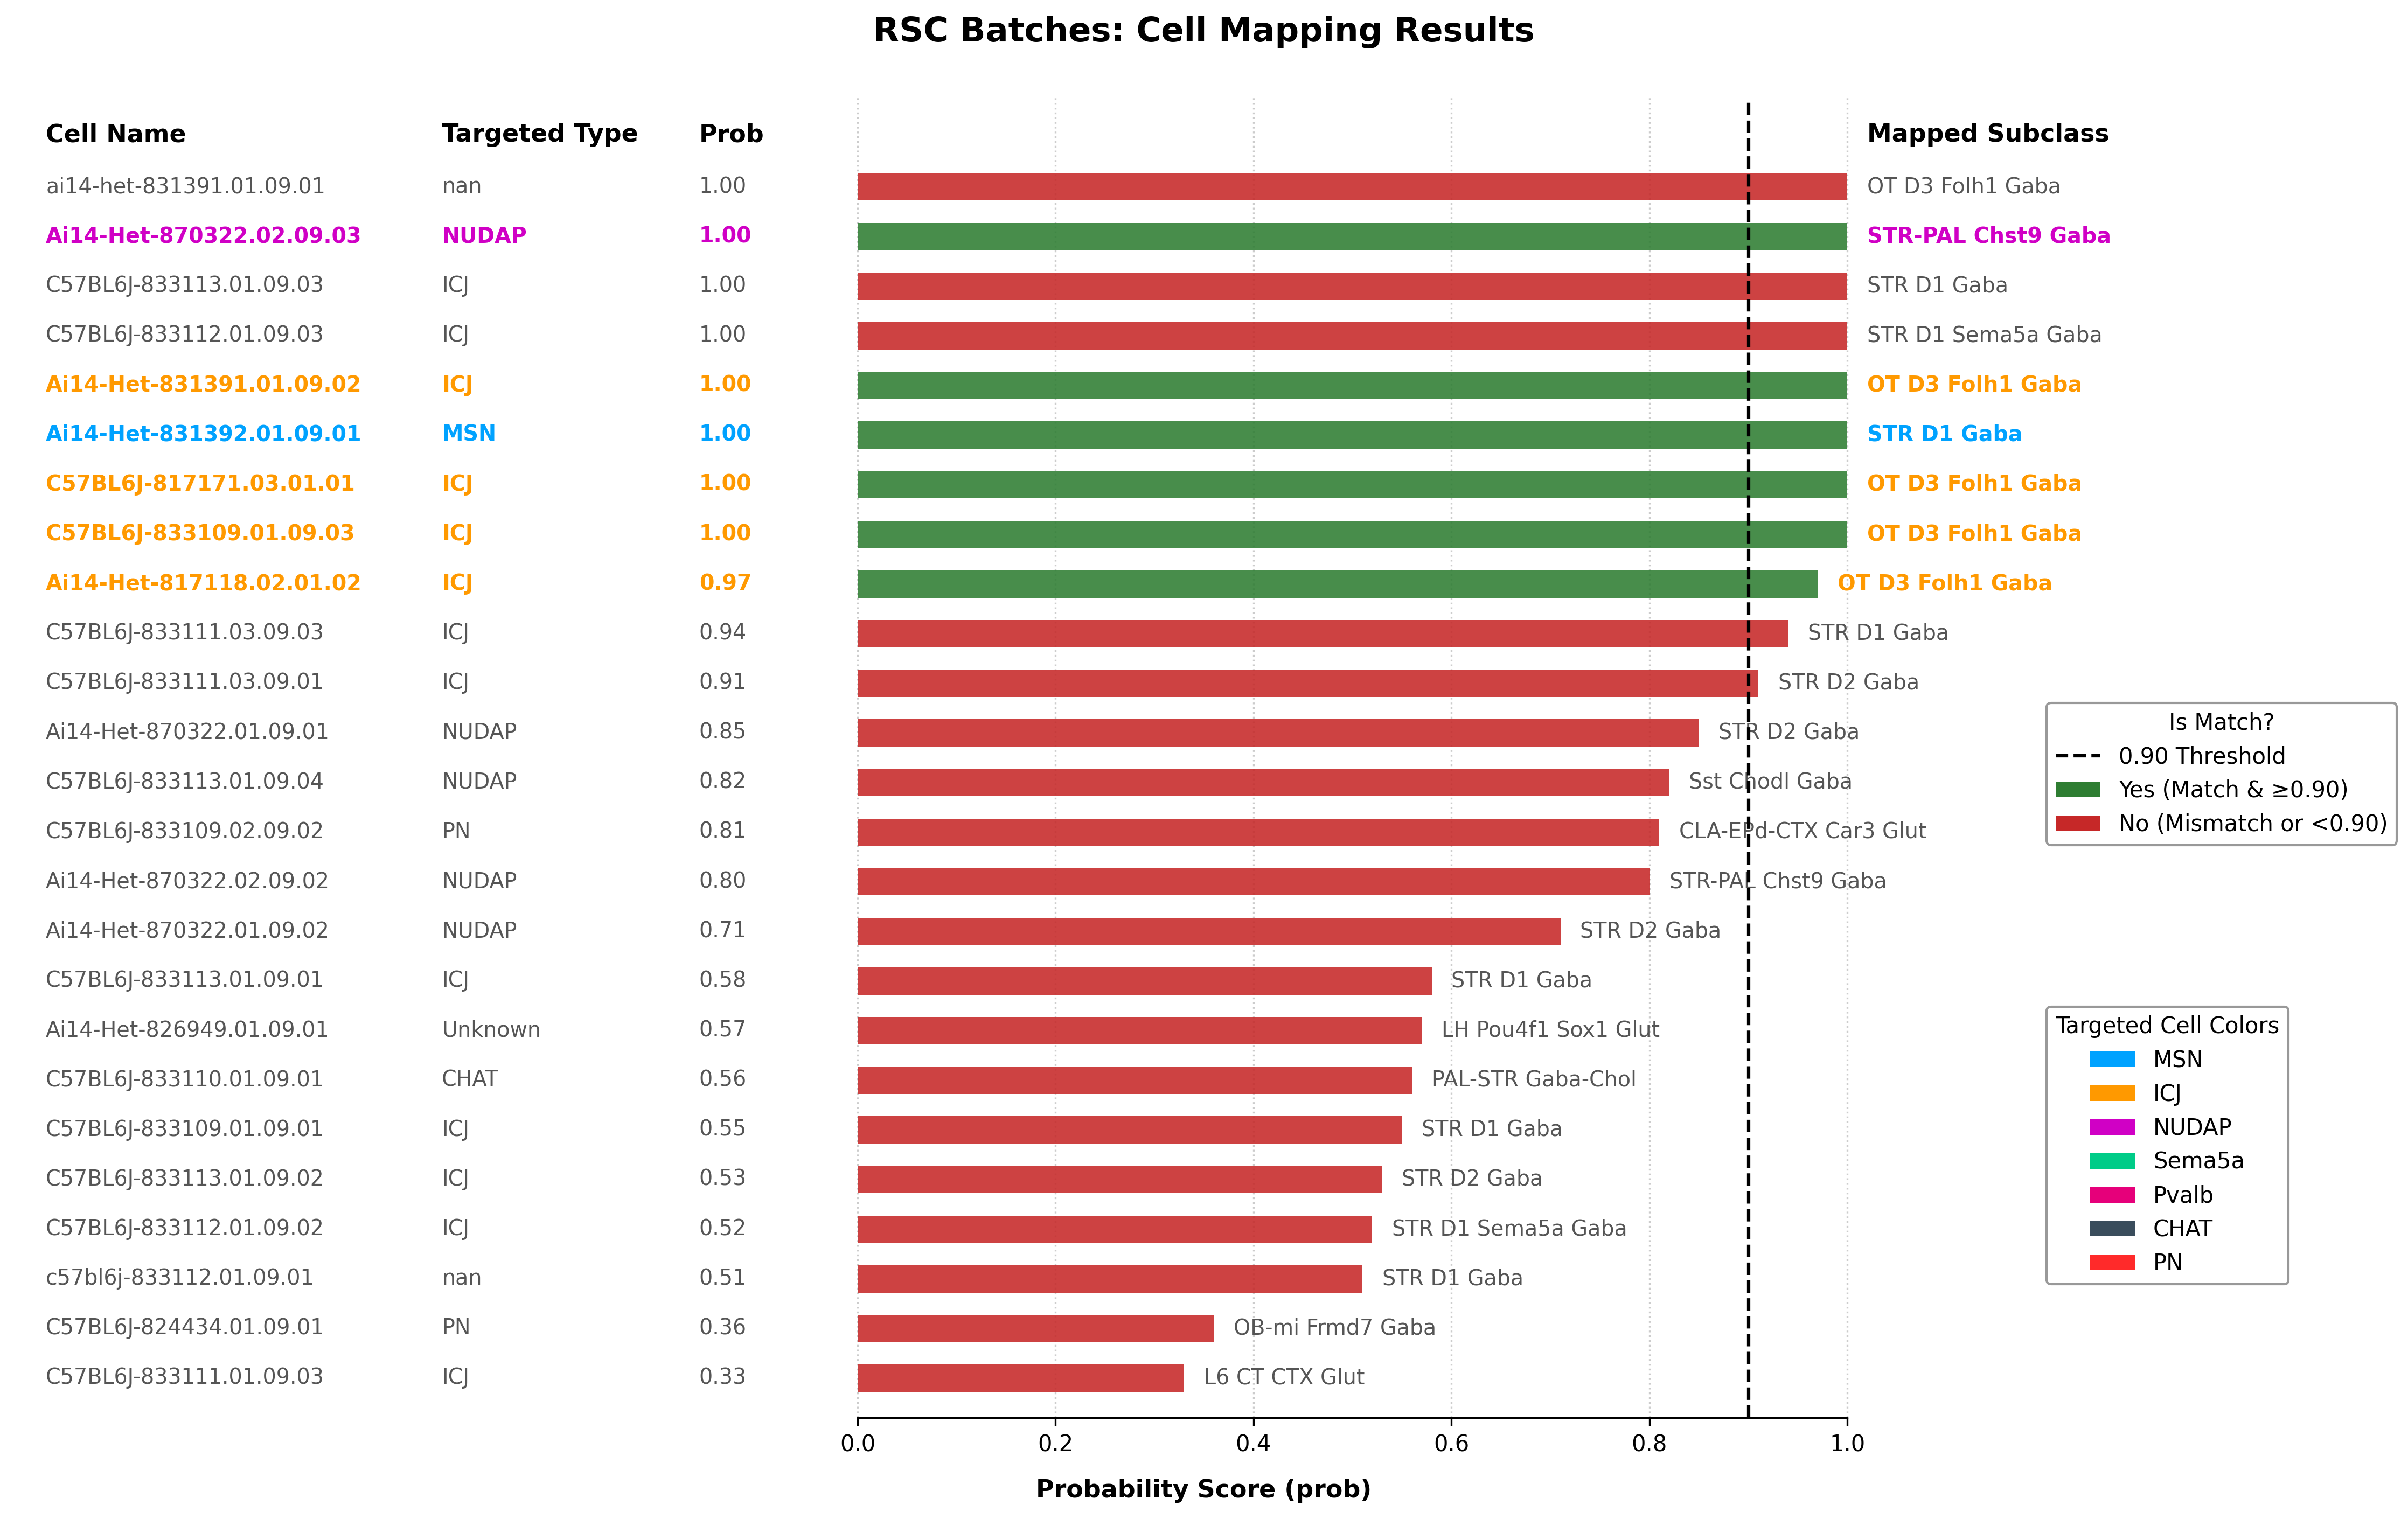

In [16]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================================================================
# 1. CLEANING & BIOLOGICAL MATCH RULES
# =============================================================================
def clean_cell_display_name(val):
    """Strips path, file extension, and device noise for publication display."""
    s = str(val).strip()
    s = os.path.basename(s)
    s = s.replace('.nwb', '').replace('_compressed', '').replace('-compressed', '')
    s = re.sub(r'_itc18usb_dev_\d+', '', s, flags=re.IGNORECASE)
    return s.strip()

def check_biological_match(targeted, mapped):
    """
    Validates if mapped transcriptomic subclass matches ground-truth targeted type:
    - ICJ    -> OT D3 Folh1 Gaba
    - MSN    -> STR D1 Gaba / STR D2 Gaba
    - NUDAP  -> STR-PAL Chst9 Gaba
    - Sema5a -> STR D1 Sema5a Gaba
    - CHAT   -> PAL-STR Gaba-Chol / CHAT
    - Pvalb  -> Pvalb
    - PN     -> Glutamatergic subclasses
    """
    t = str(targeted).strip().upper()
    m = str(mapped).strip().upper()
    
    if 'ICJ' in t:
        return any(k in m for k in ['D3', 'FOLH1', 'ICJ'])
    elif 'MSN' in t:
        return ('D1' in m or 'D2' in m) and ('CHST9' not in m) and ('D3' not in m)
    elif 'NUDAP' in t:
        return any(k in m for k in ['CHST9', 'NUDAP'])
    elif 'SEMA5A' in t:
        return 'SEMA5A' in m
    elif 'CHAT' in t or 'CHOLINERGIC' in t:
        return any(k in m for k in ['CHOL', 'CHAT'])
    elif 'PVALB' in t:
        return 'PVALB' in m
    elif any(k in t for k in ['PN', 'CTX', 'PYRAMIDAL', 'L5ET']):
        return any(k in m for k in ['GLUT', 'CAR3', 'CT'])
    return False

# =============================================================================
# 2. DATA PREPARATION
# =============================================================================
prob_col = 'prob' if 'prob' in df_merged.columns else [c for c in df_merged.columns if 'prob' in c.lower()][0]
mapped_subclass_col = 'best.subclass_label' if 'best.subclass_label' in df_merged.columns else 'best_subclass_label'
cell_name_col = 'cell_name' if 'cell_name' in df_merged.columns else 'cell_key'
target_col = 'cell_type_consolidated' if 'cell_type_consolidated' in df_merged.columns else 'cell_type_targeted'

map_df = df_merged.dropna(subset=[prob_col]).copy()
map_df[prob_col] = pd.to_numeric(map_df[prob_col], errors='coerce')
map_df = map_df.dropna(subset=[prob_col])

# Format clean display names and select top batch cells
map_df['display_cell_name'] = map_df[cell_name_col].apply(clean_cell_display_name)
map_df = map_df.sort_values(by=prob_col, ascending=True).tail(25)

THRESHOLD = 0.90
MATCH_GREEN = "#2E7D32"   # Green for Match & >= 0.90
NO_MATCH_RED = "#C62828"  # Red for Mismatch or < 0.90

TARGET_COLORS = {
    "MSN": "#00A2FF",
    "ICJ": "#FF9900",
    "NUDAP": "#D000C5",
    "Sema5a": "#00CC88",
    "Pvalb": "#E6007A",
    "CHAT": "#3A4D5C",
    "PN": "#FF2A2A",
    "Unknown": "#707070"
}

# =============================================================================
# 3. RENDER CLEAN MAPPING RESULTS FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(15, max(8, len(map_df) * 0.38)), dpi=300)

for idx, (_, row) in enumerate(map_df.iterrows()):
    p_val = row[prob_col]
    t_type = str(row[target_col]).strip()
    c_name = str(row['display_cell_name'])
    m_subclass = str(row.get(mapped_subclass_col, 'Unmapped')).strip()
    
    # Evaluate biological alignment and probability threshold
    is_bio_match = check_biological_match(t_type, m_subclass)
    is_high_prob = p_val >= THRESHOLD
    is_full_match = is_bio_match and is_high_prob
    
    bar_color = MATCH_GREEN if is_full_match else NO_MATCH_RED
    
    # Bolding rule: ONLY bold matching cells; non-matching cells stay normal weight & grey
    if is_full_match:
        f_weight = 'bold'
        t_color = TARGET_COLORS.get(t_type, "#000000")
    else:
        f_weight = 'normal'
        t_color = "#555555"
        
    # Horizontal Bar
    ax.barh(idx, p_val, color=bar_color, height=0.55, alpha=0.88, zorder=3)
    
    # Left Column Text (Structured X-offsets eliminate overlaps)
    ax.text(-0.82, idx, c_name, va='center', ha='left', fontsize=9.5, 
            fontfamily='sans-serif', fontweight=f_weight, color=t_color)
    ax.text(-0.42, idx, t_type, va='center', ha='left', fontsize=9.5, 
            fontweight=f_weight, color=t_color)
    ax.text(-0.16, idx, f"{p_val:.2f}", va='center', ha='left', fontsize=9.5, 
            fontweight=f_weight, color=t_color)
    
    # Right Column Text: Mapped Subclass
    ax.text(p_val + 0.02, idx, m_subclass, va='center', ha='left', fontsize=9.5, 
            fontweight=f_weight, color=t_color)

# Vertical Threshold Line
ax.axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=1.5, zorder=4)

# Header Row
header_y = len(map_df) - 0.2
ax.text(-0.82, header_y, "Cell Name", va='bottom', ha='left', fontsize=11, fontweight='bold')
ax.text(-0.42, header_y, "Targeted Type", va='bottom', ha='left', fontsize=11, fontweight='bold')
ax.text(-0.16, header_y, "Prob", va='bottom', ha='left', fontsize=11, fontweight='bold')
ax.text(1.02, header_y, "Mapped Subclass", va='bottom', ha='left', fontsize=11, fontweight='bold')

# Formatting Limits & Spines
ax.set_xlim(-0.85, 1.55)
ax.set_ylim(-0.8, len(map_df) + 0.8)

# STRICT X-AXIS SETTINGS: 0.0 to 1.0 ONLY (No negative numbers on axis line)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.spines['bottom'].set_bounds(0.0, 1.0) # Restricts bottom axis line strictly from 0 to 1
ax.set_xlabel("Probability Score (prob)", fontsize=11, fontweight='bold', labelpad=10)

ax.set_title("RSC Batches: Cell Mapping Results", fontsize=15, fontweight='bold', pad=25)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle=':', alpha=0.4, color='grey')
ax.set_axisbelow(True)

# LOWERED & OFFSET LEGENDS (Placed to the right, below mapped subclass header)
legend_match = [
    plt.Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='0.90 Threshold'),
    Patch(facecolor=MATCH_GREEN, label='Yes (Match & ≥0.90)'),
    Patch(facecolor=NO_MATCH_RED, label='No (Mismatch or <0.90)')
]
leg1 = ax.legend(handles=legend_match, title="Is Match?", loc='upper left', 
                 bbox_to_anchor=(0.85, 0.55), frameon=True, facecolor='white', edgecolor='grey')
ax.add_artist(leg1)

legend_target = [
    Patch(facecolor=col, label=lbl) for lbl, col in TARGET_COLORS.items() if lbl != 'Unknown'
]
ax.legend(handles=legend_target, title="Targeted Cell Colors", loc='upper left', 
          bbox_to_anchor=(0.85, 0.32), frameon=True, facecolor='white', edgecolor='grey')

plt.tight_layout()
plt.show()

Plot 1: Targeted vs. Mapped Confusion Matrix HeatmapThis single plot replaces all the individual dot clutter with an executive summary. Rows show what you targeted in the slice; columns show what the ABC Atlas mapped it to.   

Diagonal cells (Green background) = Successful matches.

Off-diagonal cells (Red background) = Specific mis-targetings.Python

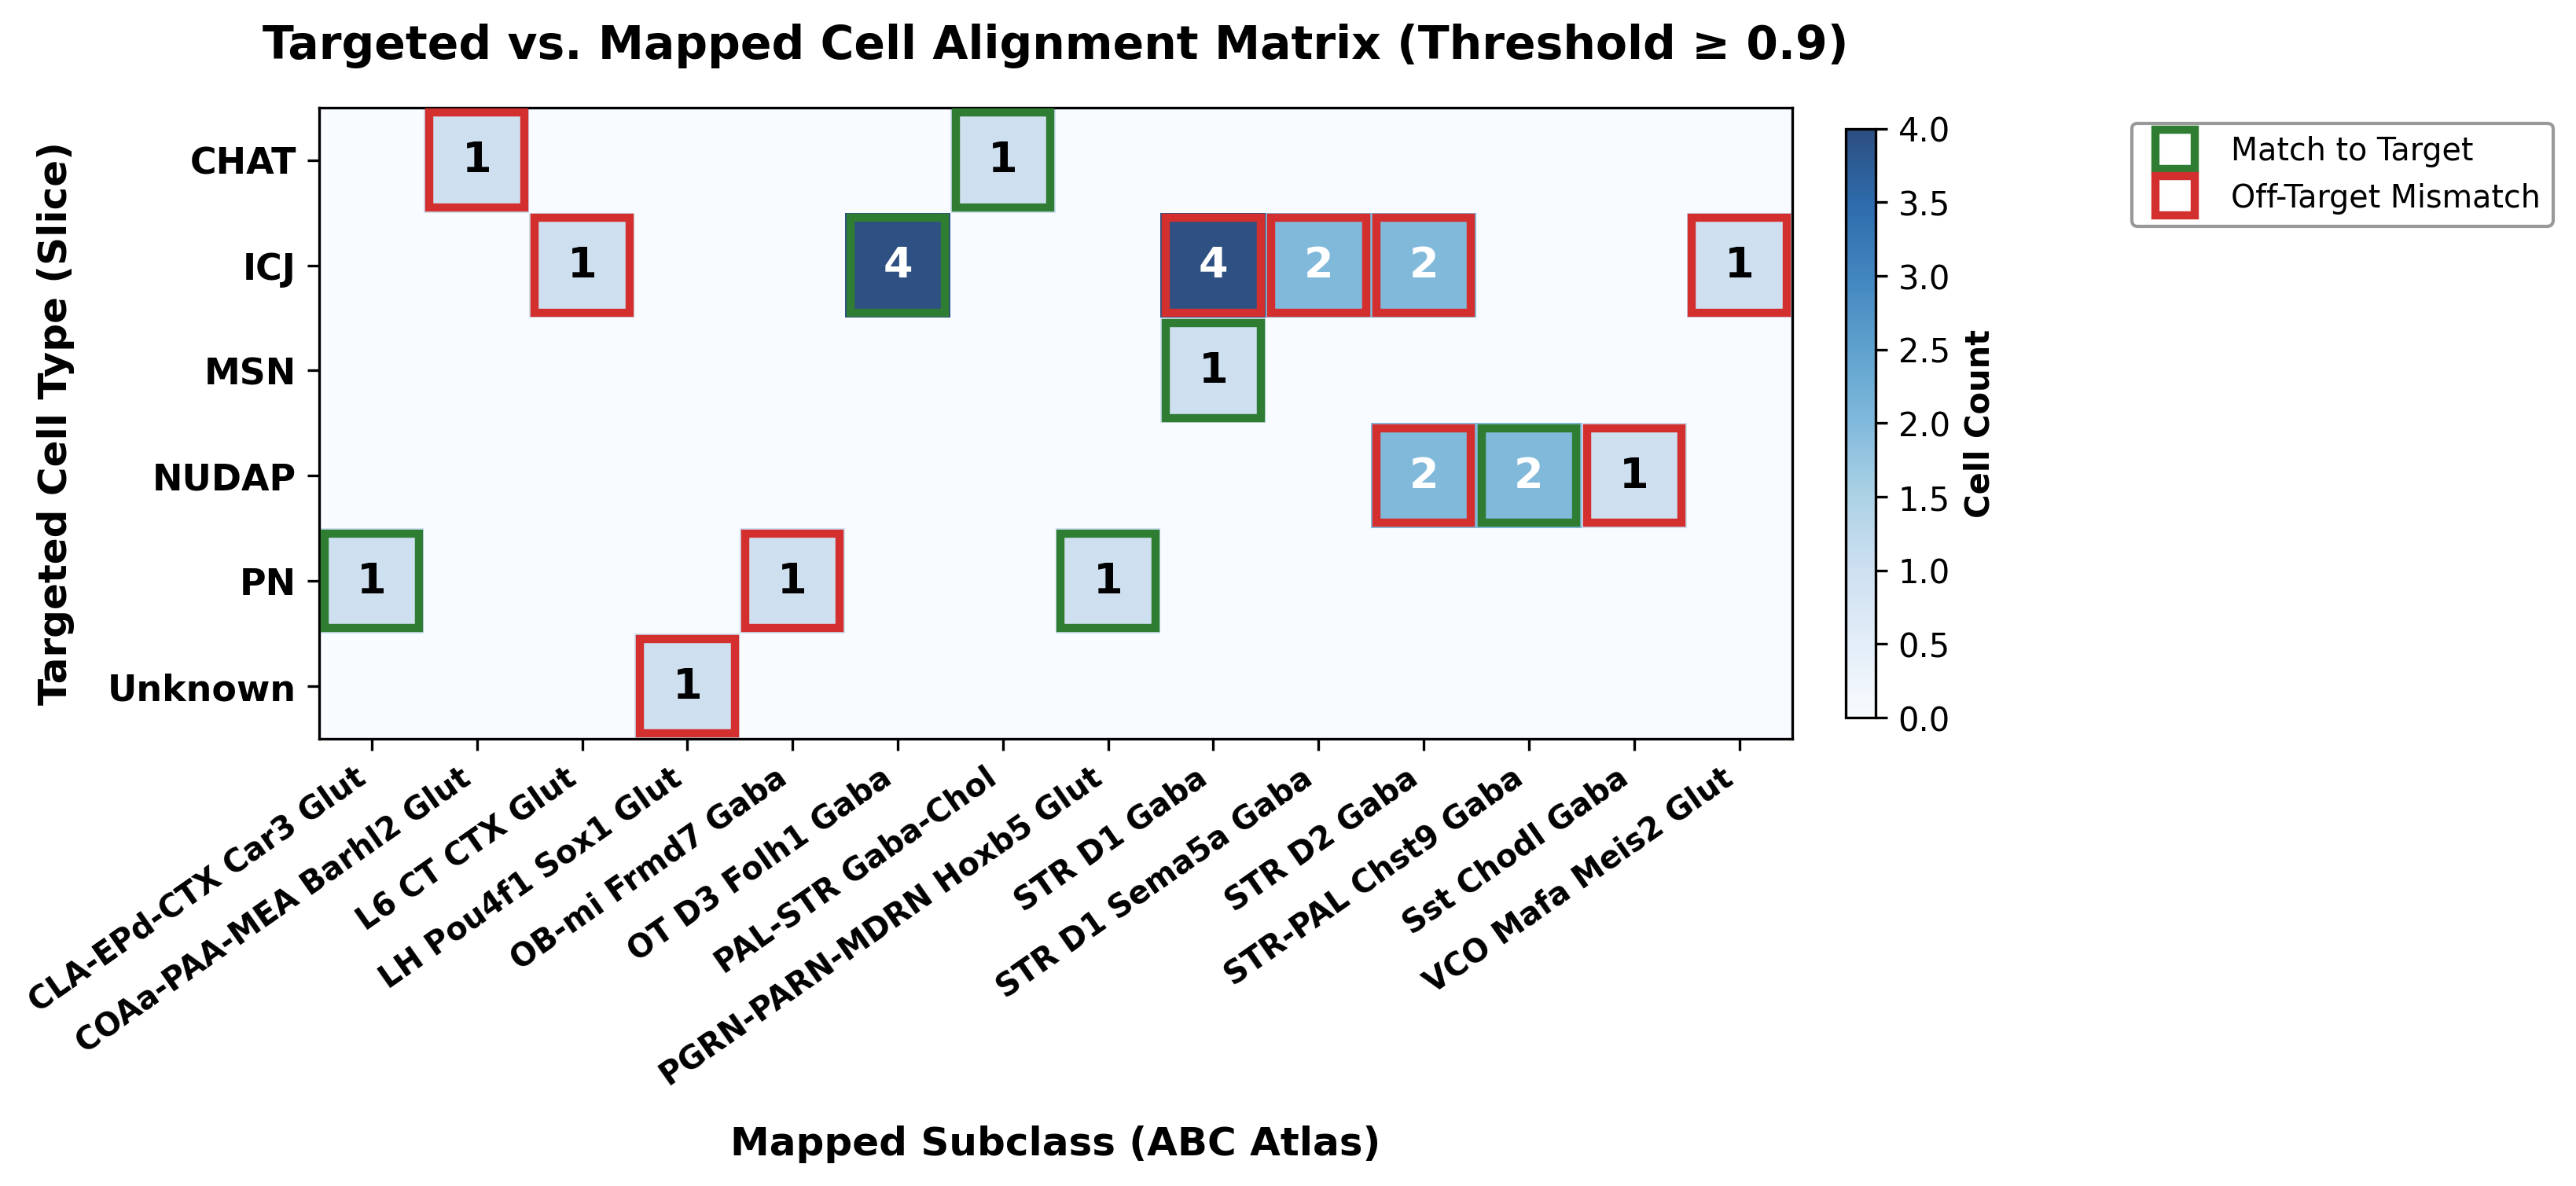

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================================================================
# PLOT 1: ALIGNMENT MATRIX WITH SQUARE LEGEND ICONS & CLEAN POSITIONING
# =============================================================================
ct = pd.crosstab(df_clean[target_col], df_clean[mapped_subclass_col])

fig, ax = plt.subplots(figsize=(11, max(5, len(ct) * 0.8)), dpi=300)
im = ax.imshow(ct.values, cmap='Blues', alpha=0.85)

max_val = ct.values.max()

for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        val = ct.values[i, j]
        if val > 0:
            t_name = ct.index[i]
            m_name = ct.columns[j]
            is_match = check_biological_match(t_name, m_name)
            
            text_color = "white" if val >= (max_val * 0.5) else "black"
            edge_color = "#2E7D32" if is_match else "#D32F2F"
            
            # Draw square border around matrix cell
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, fill=False, 
                                 edgecolor=edge_color, lw=2.5, zorder=10)
            ax.add_patch(rect)
            
            ax.text(j, i, str(val), ha='center', va='center', 
                    fontsize=13, fontweight='bold', color=text_color, zorder=11)

ax.set_xticks(np.arange(len(ct.columns)))
ax.set_yticks(np.arange(len(ct.index)))
ax.set_xticklabels(ct.columns, rotation=35, ha='right', fontweight='bold', fontsize=9.5)
ax.set_yticklabels(ct.index, fontweight='bold', fontsize=11)

ax.set_xlabel("Mapped Subclass (ABC Atlas)", fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel("Targeted Cell Type (Slice)", fontsize=12, fontweight='bold', labelpad=10)
ax.set_title(f"Targeted vs. Mapped Cell Alignment Matrix (Threshold ≥ {THRESHOLD})", fontsize=14, fontweight='bold', pad=15)

# Colorbar placement
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label("Cell Count", fontsize=10, fontweight='bold')

# EXACT SQUARE LEGEND HANDLES (Hollow squares using marker='s')
legend_square_handles = [
    Line2D([0], [0], marker='s', color='w', markeredgecolor='#2E7D32', 
           markeredgewidth=2.5, markersize=12, label='Match to Target'),
    Line2D([0], [0], marker='s', color='w', markeredgecolor='#D32F2F', 
           markeredgewidth=2.5, markersize=12, label='Off-Target Mismatch')
]

# Positioned cleanly above the colorbar without overlapping
ax.legend(
    handles=legend_square_handles, 
    loc='upper left', 
    bbox_to_anchor=(1.22, 1.0), 
    frameon=True, 
    facecolor='white', 
    edgecolor='grey',
    fontsize=9.5
)

plt.tight_layout()
plt.show()

Plot 2: Patch-seq QC Diagnostic (Matched vs. Off-Target)
This plot shows your advisor whether off-target mapping is driven by poor sample QC (low RNA reads/detected genes) or genuine physical mis-targeting (good quality RNA, but patched a neighboring cell type).

It compares Matched Cells (Green) vs. Off-Target Mismatched Cells (Red) across 4 key sequencing QC metrics:

Genes.Detected.CPM

prob (Mapping Confidence Score)

total_reads

percent_cdna_longer_than_400bp

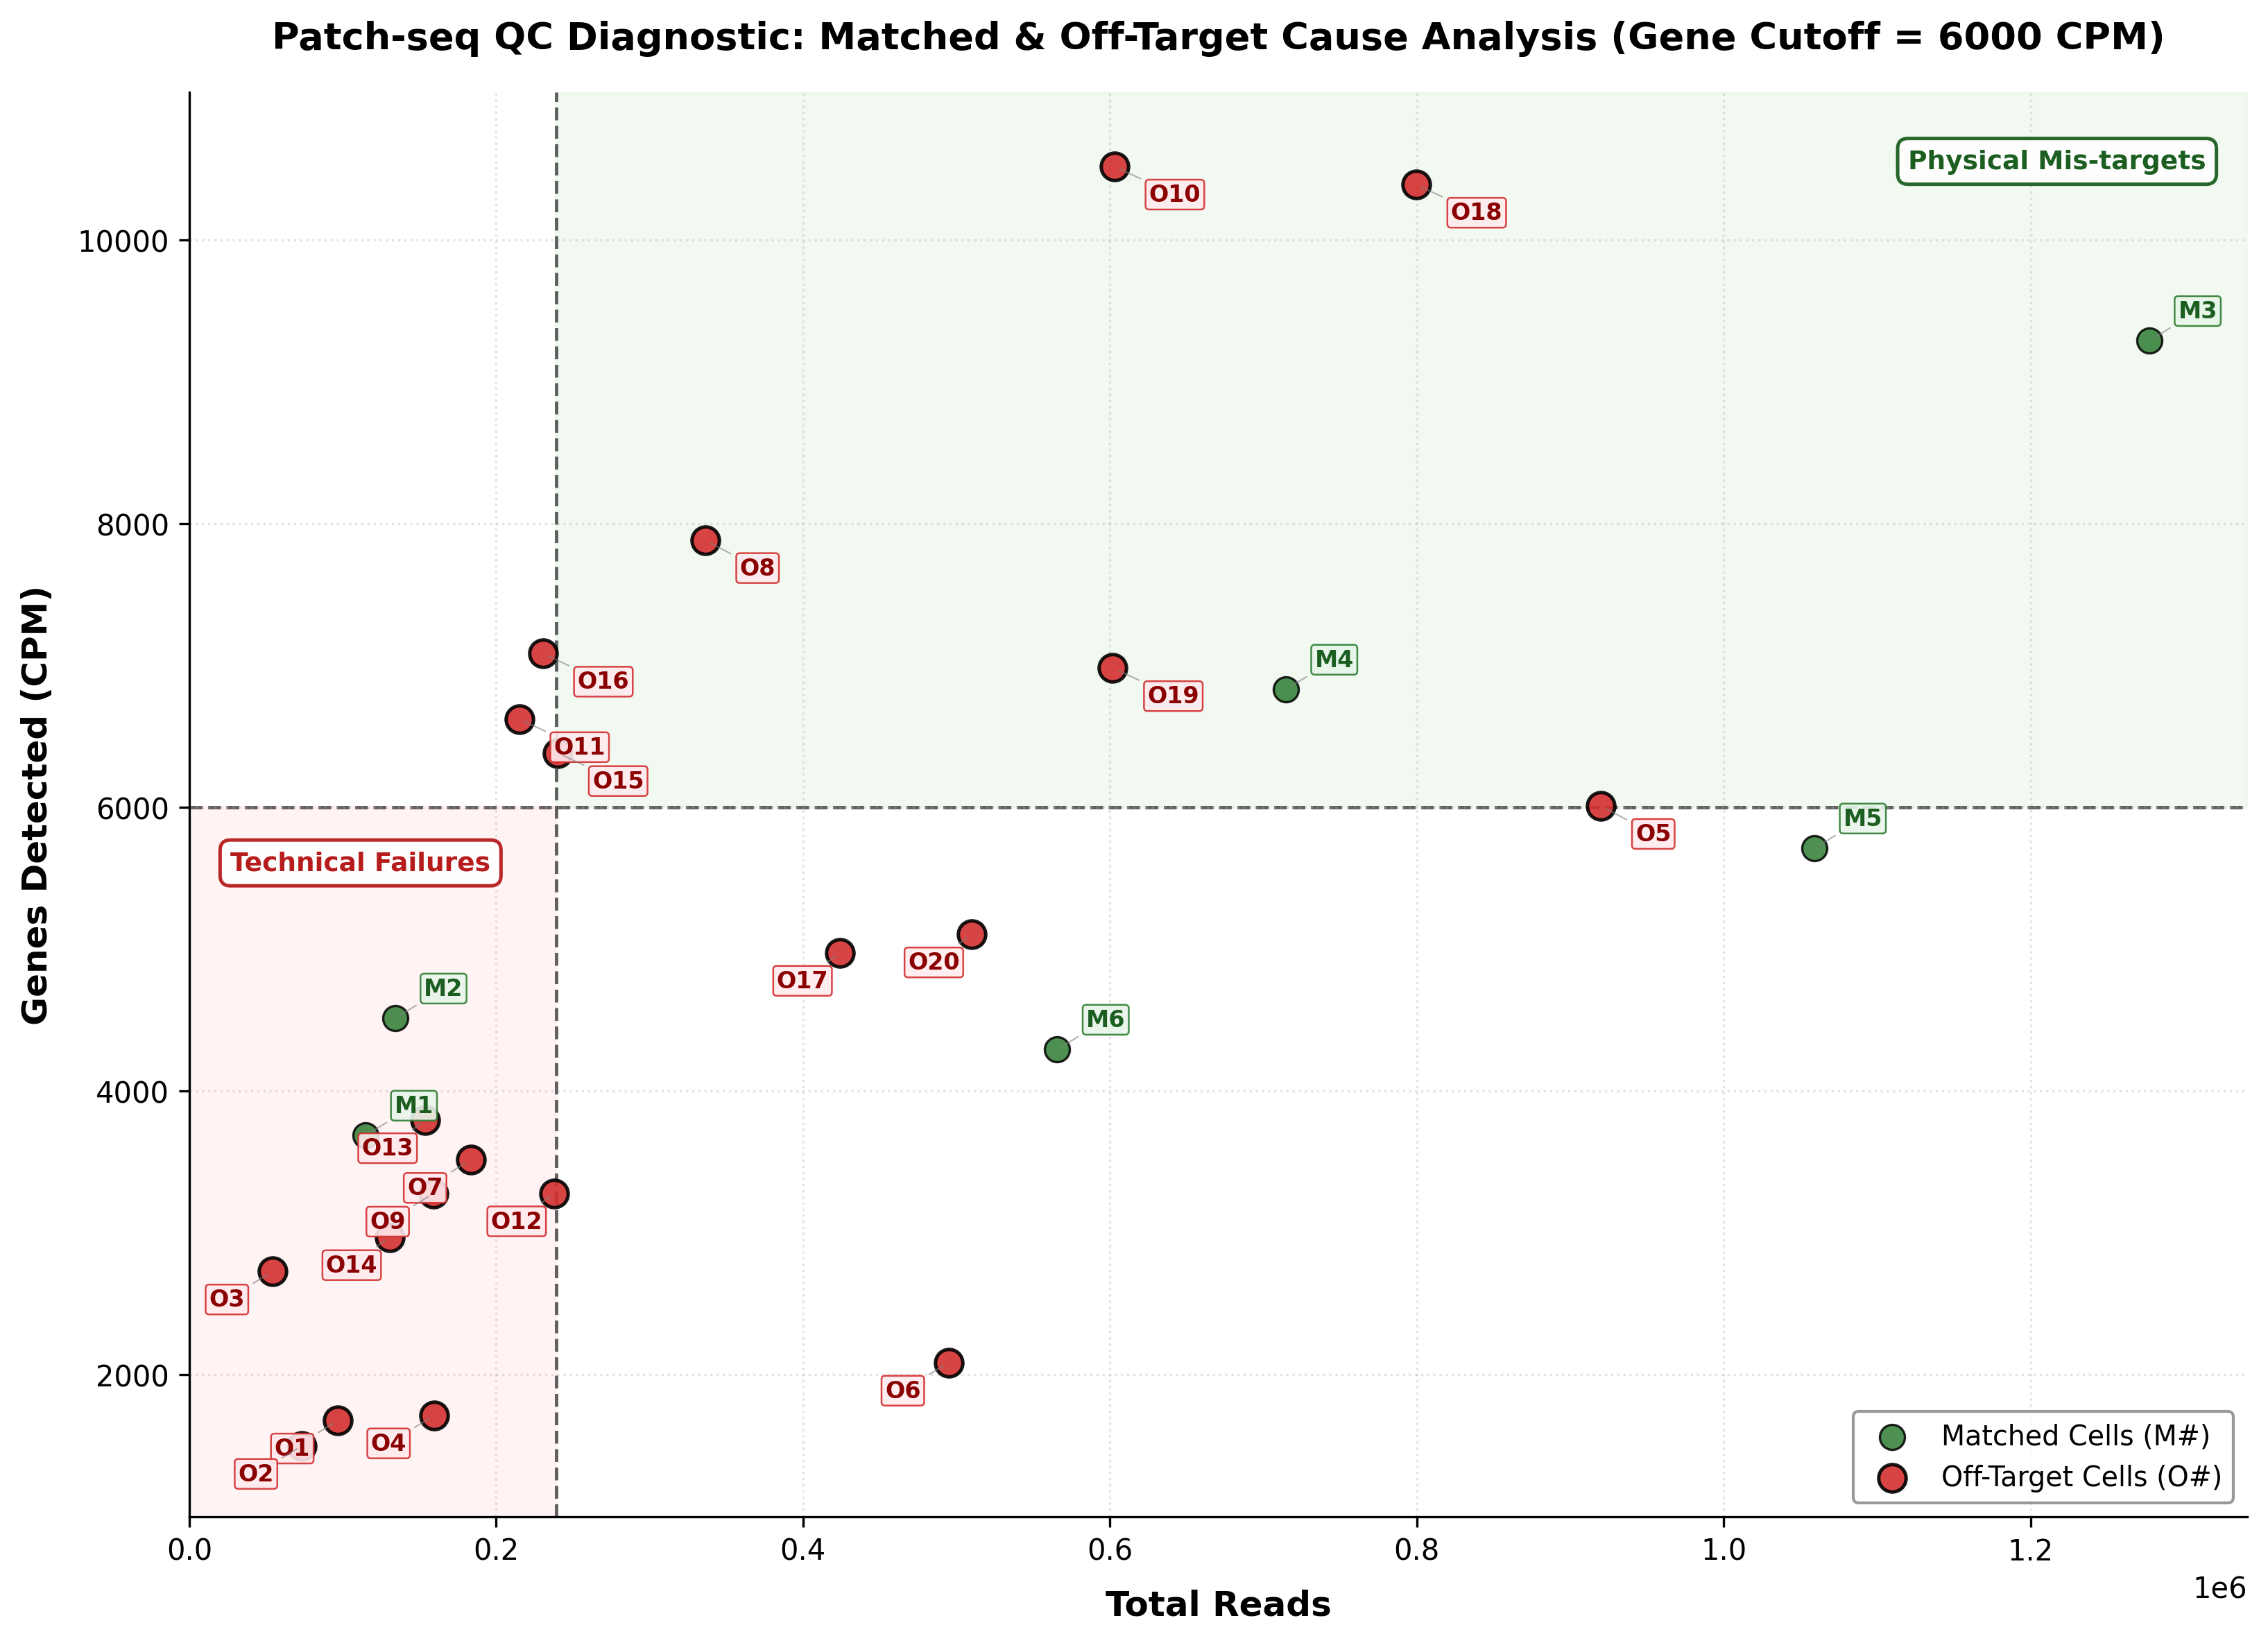

,ID,Cell Name,Date,Virus,Targeted Type,Fluorescent Label,Mapped Subclass,Prob,Total Reads,Genes CPM,Rin (MΩ),Diagnostic Category
31,O1,C57BL6J-817171.01.01.01,1970-01-01,no,ICJ,no,VCO Mafa Meis2 Glut,0.27,96933,1677,NaN,Low RNA QC / Coverage Fail ❌
37,O2,C57BL6J-824434.01.09.02,1970-01-01,no,PN,no,PGRN-PARN-MDRN Hoxb5 Glut,0.22,73270,1498,36.8,Low RNA QC / Coverage Fail ❌
38,O3,C57BL6J-824434.01.09.01,1970-01-01,no,PN,no,OB-mi Frmd7 Gaba,0.36,54316,2728,52.8,Low RNA QC / Coverage Fail ❌
46,O4,Ai14-Het-826949.01.09.01,1970-01-01,AiP15019,Unknown,no,LH Pou4f1 Sox1 Glut,0.57,159696,1713,196.2,Low RNA QC / Coverage Fail ❌
56,O5,C57BL6J-833109.02.09.02,1970-01-01,AiP15229,PN,no,CLA-EPd-CTX Car3 Glut,0.81,919922,6011,21.6,Physical Mis-target (High QC) ⚠️
58,O6,C57BL6J-833109.01.09.01,1970-01-01,AiP15229,ICJ,no,STR D1 Gaba,0.55,494837,2085,NaN,Moderate QC Mis-target ⚠️
62,O7,C57BL6J-833111.01.09.03,1970-01-01,AiP15892,ICJ,no,L6 CT CTX Glut,0.33,183461,3515,744.1,Low RNA QC / Coverage Fail ❌
63,O8,C57BL6J-833111.03.09.01,1970-01-01,AiP15892,ICJ,no,STR D2 Gaba,0.91,336124,7886,475.8,Physical Mis-target (High QC) ⚠️
65,O9,C57BL6J-833111.03.09.03,1970-01-01,AiP15892,ICJ,no,STR D1 Gaba,0.94,159074,3277,3086.2,Low RNA QC / Coverage Fail ❌
67,O10,C57BL6J-833110.01.09.01,1970-01-01,AiP15229,CHAT,no,PAL-STR Gaba-Chol,0.56,602889,10520,39.2,Physical Mis-target (High QC) ⚠️


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# =============================================================================
# 1. SETUP DATA & ASSIGN NUMBER IDs TO ALL CELLS (M1, M2... / O1, O2...)
# =============================================================================
THRESHOLD = 0.90  # Probability cutoff

reads_col = 'total_reads'
genes_col = 'Genes.Detected.CPM'
prob_col = 'prob' if 'prob' in df_merged.columns else [c for c in df_merged.columns if 'prob' in c.lower()][0]
mapped_subclass_col = 'best.subclass_label' if 'best.subclass_label' in df_merged.columns else 'best_subclass_label'
target_col = 'cell_type_consolidated' if 'cell_type_consolidated' in df_merged.columns else 'cell_type_targeted'
cell_name_col = 'cell_name' if 'cell_name' in df_merged.columns else 'cell_key'

def check_biological_match(targeted, mapped):
    t = str(targeted).strip().upper()
    m = str(mapped).strip().upper()
    if 'ICJ' in t: return any(k in m for k in ['D3', 'FOLH1', 'ICJ'])
    elif 'MSN' in t: return ('D1' in m or 'D2' in m) and ('CHST9' not in m) and ('D3' not in m)
    elif 'NUDAP' in t: return any(k in m for k in ['CHST9', 'NUDAP'])
    elif 'SEMA5A' in t: return 'SEMA5A' in m
    elif 'CHAT' in t or 'CHOLINERGIC' in t: return any(k in m for k in ['CHOL', 'CHAT'])
    elif 'PVALB' in t: return 'PVALB' in m
    elif any(k in t for k in ['PN', 'CTX', 'PYRAMIDAL', 'L5ET']): return any(k in m for k in ['GLUT', 'CAR3', 'CT'])
    return False

df_qc = df_clean.dropna(subset=[reads_col, genes_col, target_col]).copy()
df_qc[reads_col] = pd.to_numeric(df_qc[reads_col], errors='coerce')
df_qc[genes_col] = pd.to_numeric(df_qc[genes_col], errors='coerce')
df_qc[prob_col] = pd.to_numeric(df_qc[prob_col], errors='coerce').fillna(0)

# Evaluate Match Status
df_qc['is_bio_match'] = df_qc.apply(lambda r: check_biological_match(r[target_col], r[mapped_subclass_col]), axis=1)
df_qc['is_full_match'] = df_qc['is_bio_match'] & (df_qc[prob_col] >= THRESHOLD)

# Assign Number IDs to ALL Cells
df_qc['cell_plot_id'] = ""

matched_idx = df_qc[df_qc['is_full_match'] == True].index
for num, idx in enumerate(matched_idx, start=1):
    df_qc.loc[idx, 'cell_plot_id'] = f"M{num}"

off_target_idx = df_qc[df_qc['is_full_match'] == False].index
for num, idx in enumerate(off_target_idx, start=1):
    df_qc.loc[idx, 'cell_plot_id'] = f"O{num}"

# =============================================================================
# 2. RENDER QC QUADRANT DIAGNOSTIC PLOT WITH COLOR-CODED QUADRANT BACKGROUNDS
# =============================================================================
READ_CUTOFF = df_qc[reads_col].median()
GENE_CUTOFF = 6000  # Explicit 6000 CPM Cutoff

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Set initial limits based on data range
x_max = df_qc[reads_col].max() * 1.05
y_max = max(df_qc[genes_col].max() * 1.05, 11000)

ax.set_xlim(0, x_max)
ax.set_ylim(1000, y_max)

# -----------------------------------------------------------------------------
# SHADE QUADRANTS WITH BACKGROUND COLORS
# -----------------------------------------------------------------------------
# 1. Bottom-Left Quadrant (Red Tint for Low RNA QC / Coverage Failures)
ax.fill_between(
    [0, READ_CUTOFF], 1000, GENE_CUTOFF, 
    color='#FFEBEE', alpha=0.6, zorder=0, label='_nolegend_'
)

# 2. Top-Right Quadrant (Green Tint for High Quality / Physical Mis-targets)
ax.fill_between(
    [READ_CUTOFF, x_max], GENE_CUTOFF, y_max, 
    color='#E8F5E9', alpha=0.6, zorder=0, label='_nolegend_'
)

# Dashed Cutoff Lines
ax.axvline(x=READ_CUTOFF, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
ax.axhline(y=GENE_CUTOFF, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)

# -----------------------------------------------------------------------------
# PLOT DATA POINTS
# -----------------------------------------------------------------------------
# 1. Matched Cells (Green)
matched_df = df_qc[df_qc['is_full_match'] == True]
ax.scatter(
    matched_df[reads_col], matched_df[genes_col], 
    color='#2E7D32', s=75, alpha=0.85, edgecolors='black', linewidths=0.8,
    label='Matched Cells (M#)', zorder=3
)

for _, row in matched_df.iterrows():
    ax.annotate(
        row['cell_plot_id'],
        xy=(row[reads_col], row[genes_col]),
        xytext=(10, 8),
        textcoords="offset points",
        fontsize=8,
        fontweight='bold',
        color='#1B5E20',
        bbox=dict(boxstyle="round,pad=0.15", fc="#E8F5E9", ec="#2E7D32", lw=0.6, alpha=0.9),
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5, alpha=0.6),
        zorder=5
    )

# 2. Off-Target Cells (Red)
off_target_df = df_qc[df_qc['is_full_match'] == False]
ax.scatter(
    off_target_df[reads_col], off_target_df[genes_col], 
    color='#D32F2F', s=90, alpha=0.9, edgecolors='black', linewidths=1.2,
    label='Off-Target Cells (O#)', zorder=4
)

for _, row in off_target_df.iterrows():
    x_val, y_val = row[reads_col], row[genes_col]
    dx, dy = (12, -12) if y_val > GENE_CUTOFF else (-22, -12)
    
    ax.annotate(
        row['cell_plot_id'],
        xy=(x_val, y_val),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        fontweight='bold',
        color='#8B0000',
        bbox=dict(boxstyle="round,pad=0.15", fc="#FFEBEE", ec="#D32F2F", lw=0.6, alpha=0.9),
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5, alpha=0.6),
        zorder=6
    )

# -----------------------------------------------------------------------------
# QUADRANT ANNOTATION BOXES
# -----------------------------------------------------------------------------
# Top-Right Quadrant Label
ax.text(
    0.98, 0.96,
    f"Physical Mis-targets", 
    transform=ax.transAxes, fontsize=9, fontweight='bold', color='#1B5E20',
    ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#1B5E20", lw=1.2, alpha=0.95)
)

# Bottom-Left Quadrant Label
ax.text(
    0.02, 0.45,
    f"Technical Failures", 
    transform=ax.transAxes, fontsize=9, fontweight='bold', color='#B71C1C',
    ha='left', va='bottom',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#B71C1C", lw=1.2, alpha=0.95)
)

# Formatting
ax.set_xlabel("Total Reads", fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Genes Detected (CPM)", fontsize=12, fontweight='bold', labelpad=8)
ax.set_title(f"Patch-seq QC Diagnostic: Matched & Off-Target Cause Analysis (Gene Cutoff = {GENE_CUTOFF} CPM)", 
             fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.35, zorder=1)

# Clean Legend with explicit M1, M2 / O1, O2 labels
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='grey', fontsize=9.5)

plt.tight_layout()
plt.show()

# =============================================================================
# 3. GENERATE COMPLETE MASTER REFERENCE TABLE (ALL CELLS)
# =============================================================================
# =============================================================================
# EXPLICIT COLUMN DEFINITIONS: VIRUS, DATE, FLUORESCENT_LABEL
# =============================================================================
virus_col = 'virus' if 'virus' in df_qc.columns else [c for c in df_qc.columns if 'virus' in c.lower()]
date_col = 'date' if 'date' in df_qc.columns else [c for c in df_qc.columns if 'date' in c.lower()]
fluor_col = 'fluorescent_label' if 'fluorescent_label' in df_qc.columns else [c for c in df_qc.columns if 'fluor' in c.lower()]

virus_col = virus_col[0] if isinstance(virus_col, list) and len(virus_col) > 0 else virus_col
date_col = date_col[0] if isinstance(date_col, list) and len(date_col) > 0 else date_col
fluor_col = fluor_col[0] if isinstance(fluor_col, list) and len(fluor_col) > 0 else fluor_col

# =============================================================================
# BUILD MASTER SUMMARY TABLE WITH VIRUS, DATE, & FLUORESCENT_LABEL
# =============================================================================
def assign_diagnostic_category(row):
    is_match = row['is_full_match']
    high_reads = row[reads_col] >= READ_CUTOFF
    high_genes = row[genes_col] >= GENE_CUTOFF
    
    if is_match:
        return "Matched Target ✅"
    elif not high_reads and not high_genes:
        return "Low RNA QC / Coverage Fail ❌"
    elif high_reads and high_genes:
        return "Physical Mis-target (High QC) ⚠️"
    else:
        return "Moderate QC Mis-target ⚠️"

df_qc['Diagnostic_Category'] = df_qc.apply(assign_diagnostic_category, axis=1)

# Ordered Column Mapping
cols_to_show = {
    'cell_plot_id': 'ID',
    cell_name_col: 'Cell Name',
}

# Append Metadata Columns (Date, Virus, Targeted Type, Fluorescent Label)
if date_col and date_col in df_qc.columns:
    cols_to_show[date_col] = 'Date'

if virus_col and virus_col in df_qc.columns:
    cols_to_show[virus_col] = 'Virus'

cols_to_show[target_col] = 'Targeted Type'

if fluor_col and fluor_col in df_qc.columns:
    cols_to_show[fluor_col] = 'Fluorescent Label'

# Append Sequencing & Ephys Metrics
cols_to_show.update({
    mapped_subclass_col: 'Mapped Subclass',
    prob_col: 'Prob',
    reads_col: 'Total Reads',
    genes_col: 'Genes CPM',
    'input_resistance(mOhms)': 'Rin (MΩ)',
    'Diagnostic_Category': 'Diagnostic Category'
})

avail_cols = {k: v for k, v in cols_to_show.items() if k in df_qc.columns}
master_summary = df_qc[list(avail_cols.keys())].rename(columns=avail_cols)

# Format Numeric Columns
if 'Prob' in master_summary.columns: master_summary['Prob'] = master_summary['Prob'].round(2)
if 'Total Reads' in master_summary.columns: master_summary['Total Reads'] = master_summary['Total Reads'].astype(int)
if 'Genes CPM' in master_summary.columns: master_summary['Genes CPM'] = master_summary['Genes CPM'].astype(int)
if 'Rin (MΩ)' in master_summary.columns: master_summary['Rin (MΩ)'] = master_summary['Rin (MΩ)'].round(1)

# Format Date Column (YYYY-MM-DD)
if 'Date' in master_summary.columns:
    master_summary['Date'] = pd.to_datetime(master_summary['Date'], errors='coerce').dt.strftime('%Y-%m-%d').fillna(master_summary['Date'].astype(str))

# Format Fluorescent Label Column (Clean up Booleans or fill blanks)
if 'Fluorescent Label' in master_summary.columns:
    master_summary['Fluorescent Label'] = master_summary['Fluorescent Label'].replace({
        True: 'Yes', False: 'No', 1: 'Yes', 0: 'No', '1': 'Yes', '0': 'No'
    }).fillna('N/A')

# Sort: Matched first (M1..MN), then Off-Target (O1..ON)
master_summary['type_prefix'] = master_summary['ID'].str[0]
master_summary['id_num'] = master_summary['ID'].str[1:].astype(int)
master_summary = master_summary.sort_values(by=['type_prefix', 'id_num'], ascending=[False, True]).drop(columns=['type_prefix', 'id_num'])

# Save CSV
# master_summary.to_csv("master_patchseq_cells_reference_table.csv", index=False)

# print("=" * 100)
# print(f"📋 MASTER CELL REFERENCE TABLE ({len(master_summary)} total cells | Gene Cutoff = {GENE_CUTOFF} CPM)")
# print(f"💾 Saved to: master_patchseq_cells_reference_table.csv")
# print("=" * 100)

display(master_summary)

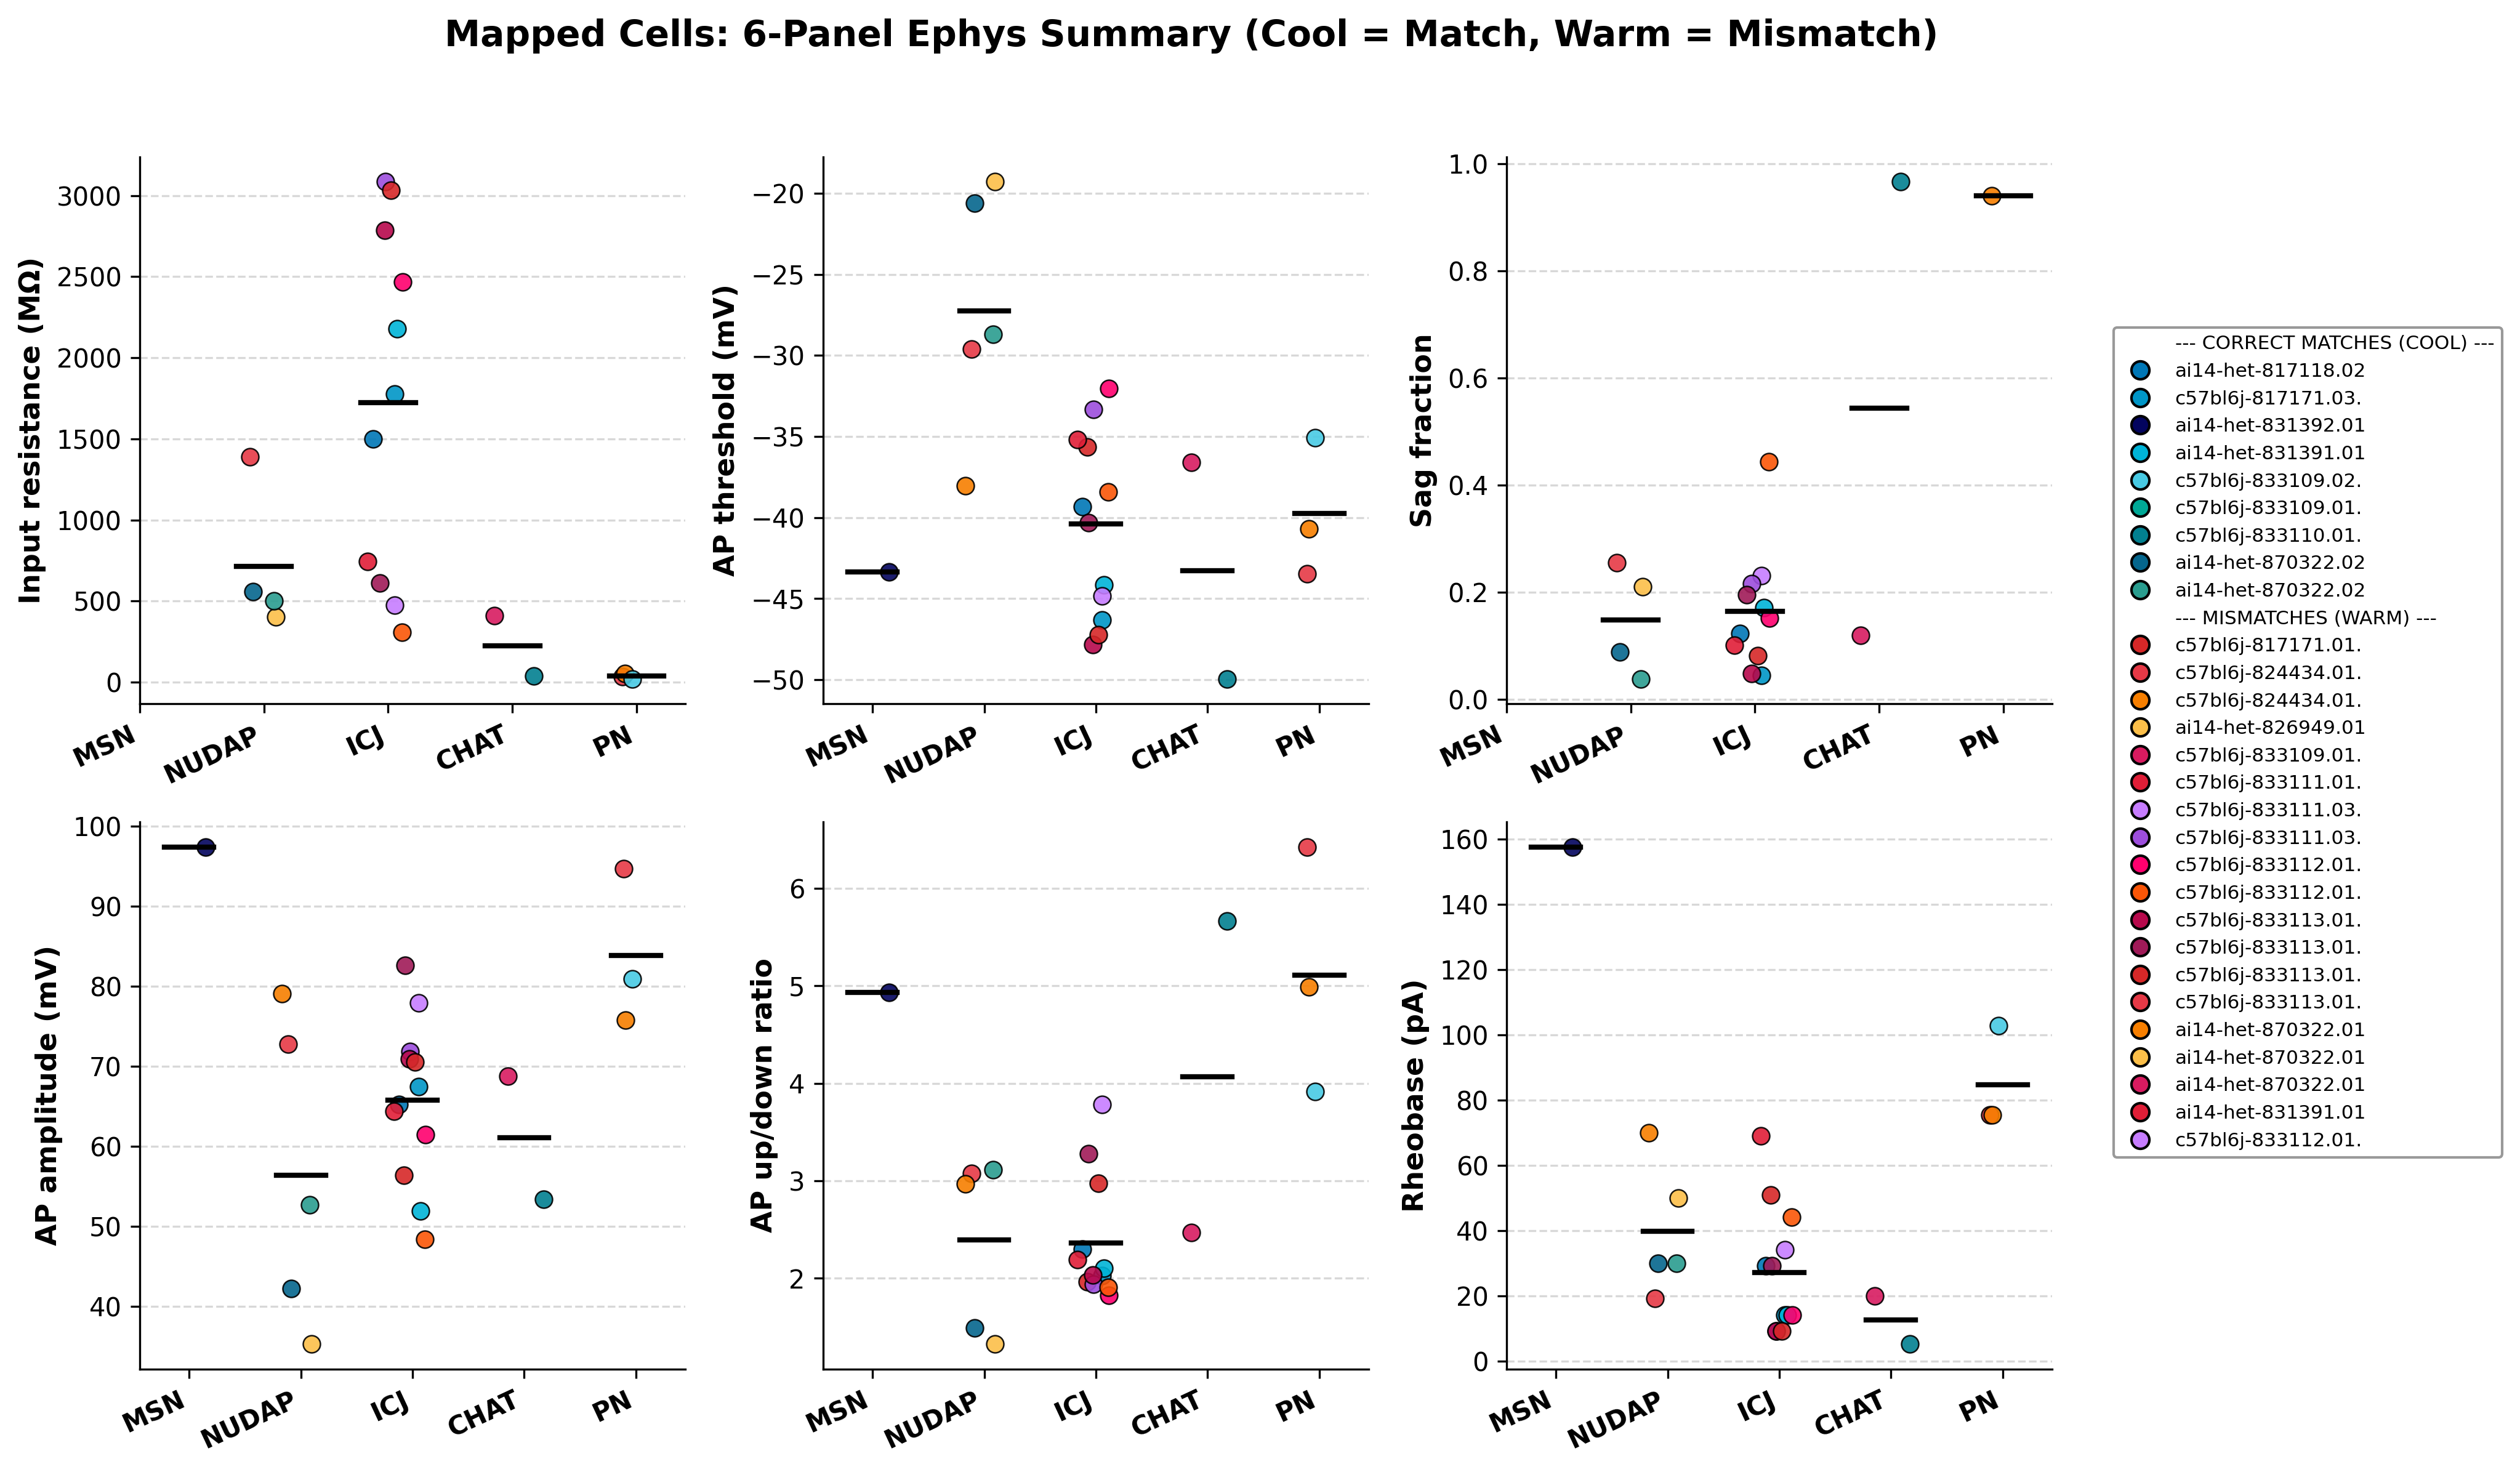

In [19]:
EPHYS_PANELS = [
    ("input_resistance(mOhms)", "Input resistance (MΩ)"),
    ("rheobase_sweep_threshold_v(mV)", "AP threshold (mV)"),
    ("sag_fraction", "Sag fraction"),
    ("rheobase_sweep_ap_amplitude(mV)", "AP amplitude (mV)"),
    ("rheobase_sweep_upstroke_downstroke_ratio", "AP up/down ratio"),
    ("rheobase_sweep_stim_amp(pA)", "Rheobase (pA)")
]

# Order of x-axis categories
ORDER = ["MSN", "NUDAP", "ICJ", "Sema5a", "Pvalb", "CHAT", "PN"]
present_groups = [g for g in ORDER if g in df_mapped[target_col].unique()]

fig, axes = plt.subplots(2, 3, figsize=(13, 8), dpi=300)
axes = axes.flatten()

for idx, (feat_col, label) in enumerate(EPHYS_PANELS):
    ax = axes[idx]
    sub_df = df_mapped.dropna(subset=[feat_col, target_col]).copy()
    
    for g_idx, grp in enumerate(present_groups):
        grp_data = sub_df[sub_df[target_col] == grp]
        if len(grp_data) == 0:
            continue
            
        # Plot each cell with its unique cool/warm color
        for c_idx, (_, row) in enumerate(grp_data.iterrows()):
            c_key = row['cell_key']
            c_val = row[feat_col]
            c_color = row['cell_color']
            
            # Deterministic small offset per cell for reproducibility
            offset = ((hash(c_key) % 100) / 100.0 - 0.5) * 0.35
            
            ax.scatter(
                g_idx + offset, c_val, 
                color=c_color, s=45, alpha=0.9, 
                edgecolors='black', linewidths=0.6, zorder=3
            )
            
        # Group Mean line marker
        mean_val = grp_data[feat_col].mean()
        ax.plot(
            [g_idx - 0.22, g_idx + 0.22], [mean_val, mean_val], 
            color='black', linewidth=2.0, zorder=5
        )

    ax.set_xticks(np.arange(len(present_groups)))
    ax.set_xticklabels(present_groups, rotation=25, ha='right', fontweight='bold', fontsize=10)
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='grey')
    ax.set_axisbelow(True)

# Build Legend: Separate into Cool (Correct) and Warm (Incorrect)
legend_handles = []

# Section Header: Correct Matches
legend_handles.append(Patch(color='none', label='--- CORRECT MATCHES (COOL) ---'))
for c_key in correct_cells:
    c_name = os.path.basename(c_key)[:18]
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cell_color_map[c_key], 
                   markeredgecolor='black', markersize=7, label=c_name)
    )

# Section Header: Mismatches
legend_handles.append(Patch(color='none', label='--- MISMATCHES (WARM) ---'))
for c_key in wrong_cells:
    c_name = os.path.basename(c_key)[:18]
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cell_color_map[c_key], 
                   markeredgecolor='black', markersize=7, label=c_name)
    )

fig.legend(
    handles=legend_handles, 
    loc='center left', 
    bbox_to_anchor=(0.88, 0.5), 
    fontsize=7.5, 
    frameon=True, 
    facecolor='white', 
    edgecolor='grey'
)

plt.suptitle("Mapped Cells: 6-Panel Ephys Summary (Cool = Match, Warm = Mismatch)", 
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 0.87, 0.96])
plt.show()